# Imports 

In [51]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import sys, json, re
from pathlib import Path
from datetime import date

import pandas as pd
import fitz
import tiktoken
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from langchain_community.document_loaders import PyMuPDFLoader

sys.path.insert(0, str(Path("..").resolve())) # because we are pulling these in a jupyter notebook, we need to add the parent directory to the path to access the system module

from system.rag import (
    LLM,
    Approaches,
    RAGExperimentRunner,
    CSVProcessor,
    LangfairMetricsCalculator,
    LangfairRunner,
    ApproachRetrievers,
)
from system.preprocess import PDFPreprocessor
from system.evaluation import (
    JudgeBatchConfig,
    JudgeBatchBuilder,
    BatchResultsConfig,
    BatchResultsExporter,
    JudgeMergeConfig,
    JudgeResultsMerger,
    CSVColumnMergeConfig,
    CSVColumnMerger,
)
from system.utils import EnvironmentConfig, read_text


MERGED = Path("../data/results/runs/multi_pdf/2026-04-17_multi_pdf_eval/merged/multi_pdf_eval.csv")
COMBINED_QA = Path("../data/results/runs/multi_pdf/2026-04-17_multi_pdf_eval/meta/combined_multi_pdf_qa.csv")

c:\Users\singhr7\Documents\safety_rag_evaluation_ryan\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [52]:
df = pd.read_csv(MERGED)
df.columns = df.columns.str.strip()

# Parse latency from "1.97 Seconds" string
df["latency_sec"] = df["total_elapsed_time"].str.extract(r"([\d\.]+)")[0].astype(float)

# Compute price per query
rates = {"nano": 0.40, "mini": 2.00}
def _rate(model):
    for k, v in rates.items():
        if k in str(model).lower():
            return v
    return 1.00
df["price_usd"] = df.apply(lambda r: (r["meta_total_tokens"] / 1_000_000) * _rate(r["model"]), axis=1)

# Cast judge booleans
for col in ["judge_answer_correctness_vs_ref", "judge_answer_helpfulness"]:
    df[col] = df[col].astype(str).str.lower().isin(["true", "1", "yes"])

# Map question -> machine
qa_map = pd.read_csv(COMBINED_QA).set_index("question")["machine"]
df["machine"] = df["question"].map(qa_map)

print(f"Rows: {len(df)}")
print(f"Approaches: {sorted(df['approach'].unique())}")
print(f"Models:     {sorted(df['model'].unique())}")
print(f"Machines:   {sorted(df['machine'].dropna().unique())}")
df.head(2)

Rows: 972
Approaches: ['long_context', 'openai_keyword', 'openai_semantic']
Models:     ['gpt-5.4-mini-2026-03-17', 'gpt-5.4-nano-2026-03-17']
Machines:   ['Lathe (HAAS TL-1)', 'Mill (Bridgeport)', 'UR5e Cobot']


,permutation_id,time_started,time_ended,total_elapsed_time,min_words_for_subsplit,approach,model,max_tokens,reasoning_effort,top_k,...,rougeL,bleu,q,judge_answer_correctness_vs_ref,judge_answer_helpfulness,text_correctness_vs_ref,text_helpfulness,latency_sec,price_usd,machine
0,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:31:29 EDT,2026-04-17 10:31:38 EDT,8.76 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.095238,0.003962,DANGER\r\nDANGER indicates a hazardous situati...,False,False,Correctness: False\n\nStep-by-step reasoning:\...,Relevance: False\n\nStep-by-step reasoning:\n-...,8.76,0.016870,Mill (Bridgeport)
1,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:31:29 EDT,2026-04-17 10:31:35 EDT,5.70 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.171779,0.006596,DANGER(Red with white text)\r\nDANGER indicate...,False,False,Correctness: False\n\nStep-by-step reasoning:\...,Relevance: False\n\nStep-by-step reasoning:\n-...,5.70,0.014984,Mill (Bridgeport)


## Crop PDFs

Crop all 3 manuals to remove headers/footers and reduce token count.

In [53]:
PDF_DIR = Path("../data/input/input_pdfs")
CROP_DIR = Path("../data/input/cropped_pdfs")
CROP_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = {
    "Mill (Bridgeport)": {
        "path": PDF_DIR / "Bridgeport Series 1 Milling manual with schematics.pdf",
        "crop_top": 0.04, "crop_bottom": 0.075, "crop_left": 0.0, "crop_right": 0.0,
    },
    "Lathe (HAAS TL-1)": {
        "path": PDF_DIR / "TL1_lathe operator's-manual.pdf",
        "crop_percent": 0.075,
    },
    "UR5e Cobot": {
        "path": PDF_DIR / "UR5e_Universal_Robots User Manual.pdf",
        "crop_percent": 0.075,
    },
}

CROPPED = {}
for label, cfg in TARGETS.items():
    out = CROP_DIR / f"cropped_{cfg['path'].name}"
    PDFPreprocessor.crop_pdf(
        cfg["path"], out,
        crop_percent=cfg.get("crop_percent", 0.075),
        crop_top=cfg.get("crop_top"),
        crop_bottom=cfg.get("crop_bottom"),
        crop_left=cfg.get("crop_left"),
        crop_right=cfg.get("crop_right"),
    )
    CROPPED[label] = out
    print(f"Cropped {label} -> {out.name}")

Cropped Mill (Bridgeport) -> cropped_Bridgeport Series 1 Milling manual with schematics.pdf
Cropped Lathe (HAAS TL-1) -> cropped_TL1_lathe operator's-manual.pdf
Cropped UR5e Cobot -> cropped_UR5e_Universal_Robots User Manual.pdf


In [54]:
def load_pdf_as_text(path) -> str:
    pages = PyMuPDFLoader(str(path)).load()
    return "\n\n".join(p.page_content for p in pages).strip()

enc = tiktoken.get_encoding("cl100k_base")
cropped_texts = {}
total_tokens = 0

for label in TARGETS:
    text = load_pdf_as_text(CROPPED[label])
    cropped_texts[label] = text
    n_tokens = len(enc.encode(text))
    total_tokens += n_tokens
    print(f"{label:25s}  {len(text):>10,} chars   {n_tokens:>8,} tokens")

print(f"\n{'COMBINED':25s}  {'':>10s}        {total_tokens:>8,} tokens")

Mill (Bridgeport)             121,502 chars     45,319 tokens
Lathe (HAAS TL-1)             557,235 chars    154,558 tokens
UR5e Cobot                    253,244 chars     60,754 tokens

COMBINED                                      260,631 tokens


# General

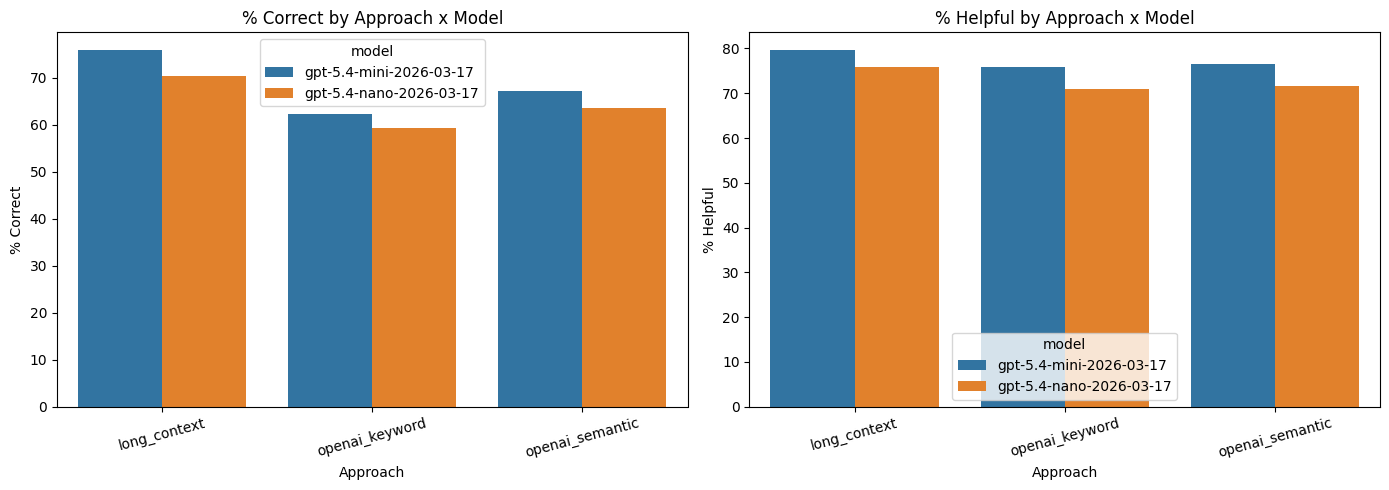

,approach,model,pct_correct,pct_helpful
0,long_context,gpt-5.4-mini-2026-03-17,75.925926,79.629630
1,long_context,gpt-5.4-nano-2026-03-17,70.370370,75.925926
4,openai_semantic,gpt-5.4-mini-2026-03-17,67.283951,76.543210
5,openai_semantic,gpt-5.4-nano-2026-03-17,63.580247,71.604938
2,openai_keyword,gpt-5.4-mini-2026-03-17,62.345679,75.925926
3,openai_keyword,gpt-5.4-nano-2026-03-17,59.259259,70.987654


In [3]:
# Chart 1: Correctness & Helpfulness by Approach x Model
agg = (
    df.groupby(["approach", "model"])
    .agg(
        pct_correct=("judge_answer_correctness_vs_ref", lambda x: x.mean() * 100),
        pct_helpful=("judge_answer_helpfulness", lambda x: x.mean() * 100),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=agg, x="approach", y="pct_correct", hue="model", ax=axes[0])
axes[0].set_title("% Correct by Approach x Model")
axes[0].set_xlabel("Approach"); axes[0].set_ylabel("% Correct")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=agg, x="approach", y="pct_helpful", hue="model", ax=axes[1])
axes[1].set_title("% Helpful by Approach x Model")
axes[1].set_xlabel("Approach"); axes[1].set_ylabel("% Helpful")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()
display(agg.sort_values("pct_correct", ascending=False))

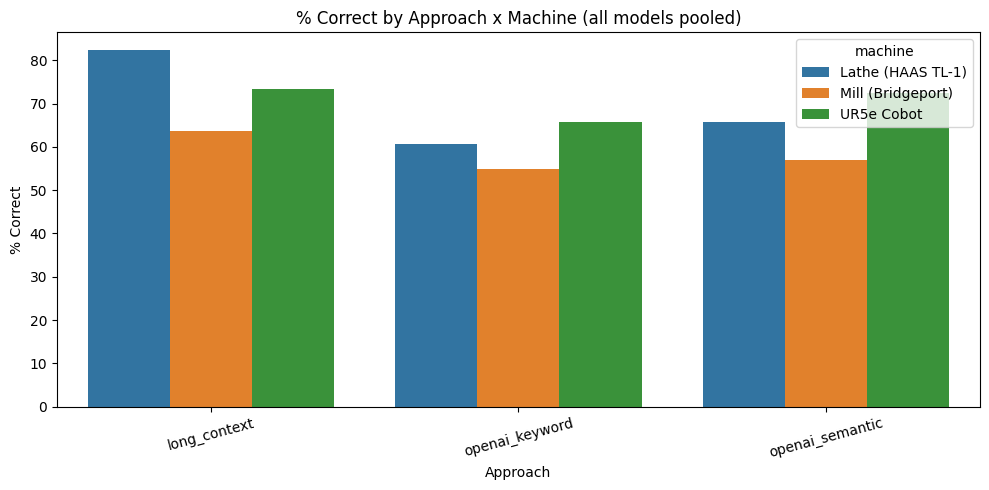

,approach,machine,pct_correct
0,long_context,Lathe (HAAS TL-1),82.352941
2,long_context,UR5e Cobot,73.333333
8,openai_semantic,UR5e Cobot,72.500000
5,openai_keyword,UR5e Cobot,65.833333
6,openai_semantic,Lathe (HAAS TL-1),65.686275
1,long_context,Mill (Bridgeport),63.725490
3,openai_keyword,Lathe (HAAS TL-1),60.784314
7,openai_semantic,Mill (Bridgeport),56.862745
4,openai_keyword,Mill (Bridgeport),54.901961


In [4]:
# Chart 2: Per-Machine Correctness — Approach x Machine
agg_machine = (
    df.groupby(["approach", "machine"])
    .agg(pct_correct=("judge_answer_correctness_vs_ref", lambda x: x.mean() * 100))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=agg_machine, x="approach", y="pct_correct", hue="machine", ax=ax)
ax.set_title("% Correct by Approach x Machine (all models pooled)")
ax.set_xlabel("Approach"); ax.set_ylabel("% Correct")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()
display(agg_machine.sort_values("pct_correct", ascending=False))

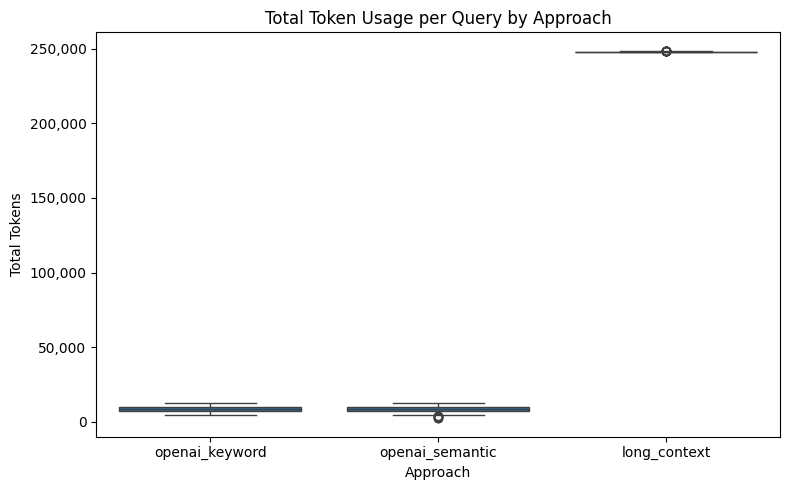

                count     mean    std      min      25%      50%      75%  \
approach                                                                    
long_context      324  247,917    111  247,772  247,842  247,891  247,955   
openai_keyword    324    8,743  1,759    4,579    7,525    8,766    9,904   
openai_semantic   324    8,563  1,783    2,498    7,567    8,694    9,778   

                     max  
approach                  
long_context     248,635  
openai_keyword    12,661  
openai_semantic   12,567  


C:\Users\singhr7\AppData\Local\Temp\ipykernel_26404\189375081.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df.groupby("approach")["meta_total_tokens"].describe().applymap(lambda x: f"{x:,.0f}"))


In [5]:
# Chart 3: Token Usage Distribution by Approach
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="approach", y="meta_total_tokens", ax=ax)
ax.set_title("Total Token Usage per Query by Approach")
ax.set_xlabel("Approach"); ax.set_ylabel("Total Tokens")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()
print(df.groupby("approach")["meta_total_tokens"].describe().applymap(lambda x: f"{x:,.0f}"))

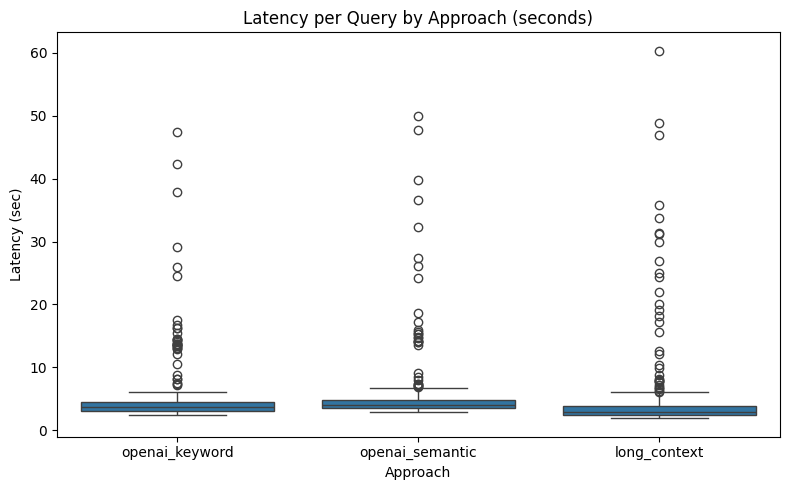

                 count  mean   std   min   25%   50%   75%    max
approach                                                         
long_context     324.0  4.69  6.70  1.90  2.42  2.82  3.88  60.36
openai_keyword   324.0  5.09  5.06  2.46  3.12  3.63  4.54  47.48
openai_semantic  324.0  5.40  5.55  2.88  3.50  4.00  4.82  49.97


In [6]:
# Chart 4: Latency Distribution by Approach
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="approach", y="latency_sec", ax=ax)
ax.set_title("Latency per Query by Approach (seconds)")
ax.set_xlabel("Approach"); ax.set_ylabel("Latency (sec)")
plt.tight_layout()
plt.show()
print(df.groupby("approach")["latency_sec"].describe().round(2))

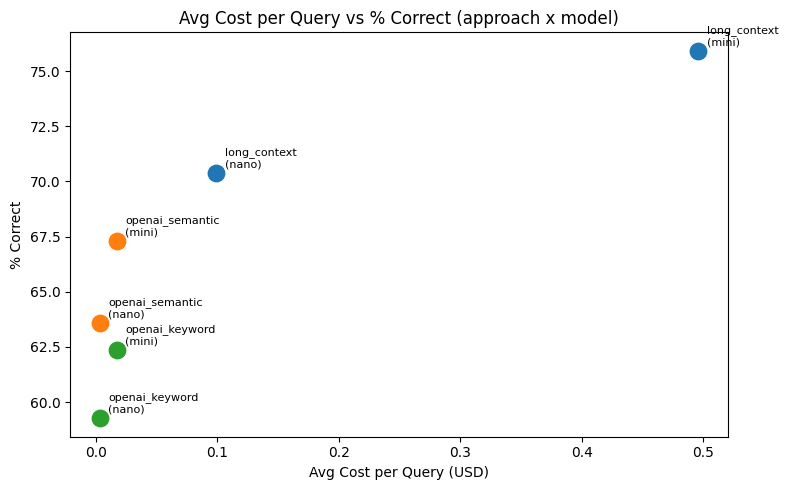

,approach,model,avg_cost,pct_correct
0,long_context,gpt-5.4-mini-2026-03-17,0.495788,75.925926
1,long_context,gpt-5.4-nano-2026-03-17,0.099176,70.370370
4,openai_semantic,gpt-5.4-mini-2026-03-17,0.017128,67.283951
5,openai_semantic,gpt-5.4-nano-2026-03-17,0.003425,63.580247
2,openai_keyword,gpt-5.4-mini-2026-03-17,0.017519,62.345679
3,openai_keyword,gpt-5.4-nano-2026-03-17,0.003490,59.259259


In [7]:
# Chart 5: Cost vs Correctness Scatter (aggregated — one point per approach x model)
agg_cost = (
    df.groupby(["approach", "model"])
    .agg(
        avg_cost=("price_usd", "mean"),
        pct_correct=("judge_answer_correctness_vs_ref", lambda x: x.mean() * 100),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = {"long_context": "tab:blue", "openai_semantic": "tab:orange", "openai_keyword": "tab:green"}
for _, row in agg_cost.iterrows():
    model_short = "mini" if "mini" in row["model"] else "nano"
    ax.scatter(row["avg_cost"], row["pct_correct"],
               s=140, color=colors.get(row["approach"], "gray"), zorder=3)
    ax.annotate(f"{row['approach']}\n({model_short})",
                (row["avg_cost"], row["pct_correct"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_title("Avg Cost per Query vs % Correct (approach x model)")
ax.set_xlabel("Avg Cost per Query (USD)")
ax.set_ylabel("% Correct")
plt.tight_layout()
plt.show()
display(agg_cost.sort_values("pct_correct", ascending=False))

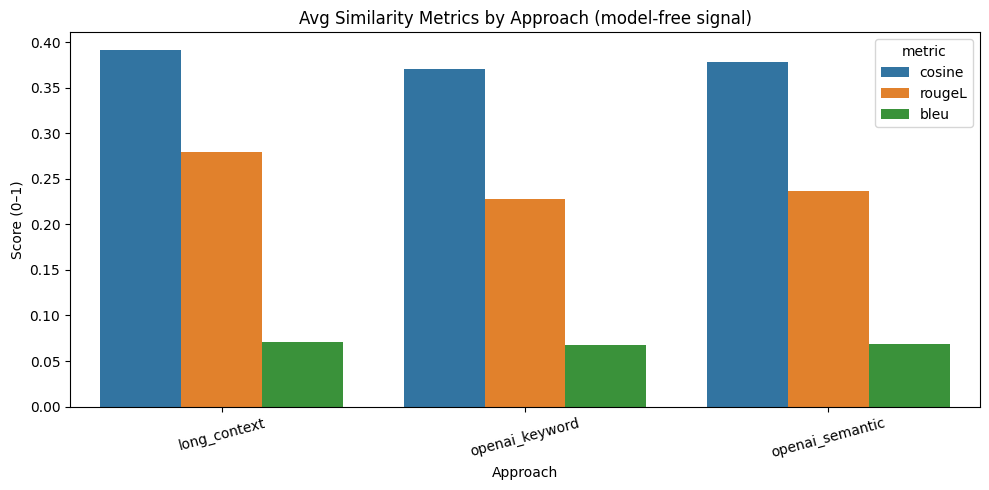

,cosine,rougeL,bleu
approach,,,
long_context,0.391,0.279,0.070
openai_keyword,0.370,0.228,0.067
openai_semantic,0.378,0.237,0.069


In [8]:
# Chart 6: Similarity Metrics (cosine / rougeL / bleu) by Approach
agg_sim = (
    df.groupby("approach")[["cosine", "rougeL", "bleu"]]
    .mean()
    .reset_index()
    .melt(id_vars="approach", var_name="metric", value_name="score")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=agg_sim, x="approach", y="score", hue="metric", ax=ax)
ax.set_title("Avg Similarity Metrics by Approach (model-free signal)")
ax.set_xlabel("Approach"); ax.set_ylabel("Score (0–1)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()
display(df.groupby("approach")[["cosine", "rougeL", "bleu"]].mean().round(3))

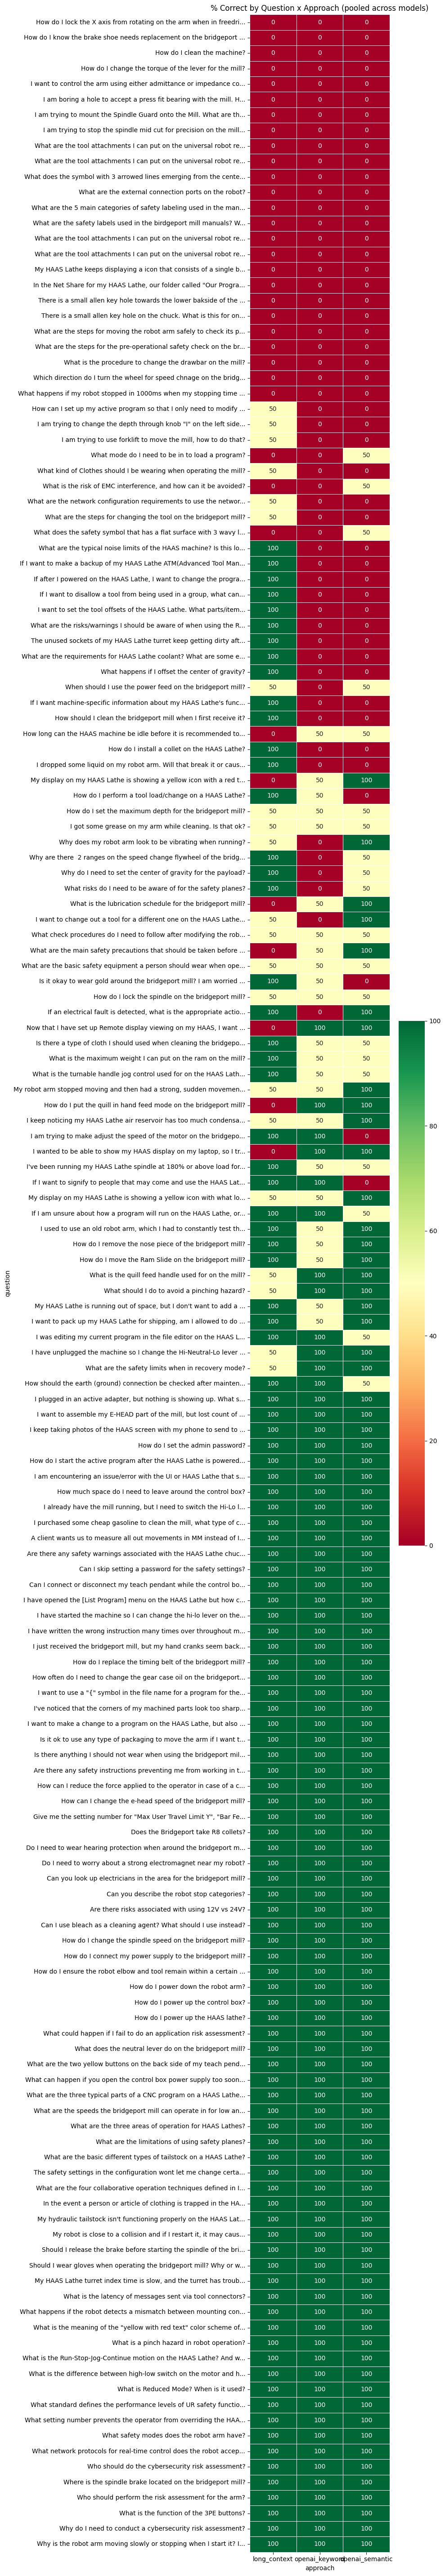

In [9]:
# Chart 7: Heatmap — Question x Approach correctness (pooled across models)
piv = (
    df.groupby(["question", "approach"])["judge_answer_correctness_vs_ref"]
    .mean()
    .unstack("approach") * 100
)
piv.index = piv.index.map(lambda q: q[:65] + "..." if len(q) > 65 else q)
piv = piv.loc[piv.mean(axis=1).sort_values().index]  # hardest at top

fig, ax = plt.subplots(figsize=(10, max(18, len(piv) * 0.35)))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100, linewidths=0.5, ax=ax)
ax.set_title("% Correct by Question x Approach (pooled across models)")
plt.tight_layout()
plt.show()

In [10]:
# Chart 8: Universally Missed Questions (0% correct across all approaches + models)
q_overall = df.groupby("question")["judge_answer_correctness_vs_ref"].mean() * 100
zero_qs = q_overall[q_overall == 0].index.tolist()
print(f"{len(zero_qs)} questions scored 0% across ALL approaches and models:\n")

for i, q in enumerate(zero_qs, 1):
    print("=" * 80)
    print(f"Q{i}: {q}\n")
    gold = df.loc[df["question"] == q, "gold_answer"].iloc[0]
    print(f"GOLD ANSWER:\n{gold}\n")
    sample = df.loc[df["question"] == q].iloc[0]
    print(f"SAMPLE ({sample['approach']}, {sample['model']}):")
    print(f"{str(sample['generated_answer'])[:500]}\n")

23 questions scored 0% across ALL approaches and models:

Q1: How do I change the torque of the lever for the mill?

GOLD ANSWER:
You can change this using hi-lo mechanical lever. 

The Hi-Neutral-Lo Lever “O”, Figure 2.13, is used to put the attachment into either back gear or
direct drive. Rotate the spindle by hand to facilitate meshing of clutch or gears.

SAMPLE (openai_keyword, gpt-5.4-mini-2026-03-17):
The provided documents do not explain how to change the torque of the lever for the mill. They only list parts for the power feed assemblies, including standard torque and high torque motor options. [009__L1__Chapter_4_-_Parts_Listings__pp63-114__L2__14__6F_Power_Feed_X-Axis__pp97-99.pdf] [009__L1__Chapter_4_-_Parts_Listings__pp63-114__L2__15__8F_Power_Feed_X-Axis__pp100-103.pdf]

Q2: How do I clean the machine?

GOLD ANSWER:
Prepare the surface by removing loose dirt or debris. Apply a cleaning agent to the surface that needs cleaning, agitater the agent for stubborn spots, let t

In [11]:
cobot_df = df[df["machine"] == "UR5e Cobot"]

In [12]:
# ============================================================
# UR5e Cobot Analysis
# ============================================================

cobot_df = df[df["machine"] == "UR5e Cobot"].copy()

print(f"Rows for UR5e Cobot: {len(cobot_df)}")
print(f"Questions: {cobot_df['question'].nunique()}")
print(f"Approaches: {sorted(cobot_df['approach'].unique())}")
print(f"Models: {sorted(cobot_df['model'].unique())}")

# ------------------------------------------------------------
# 1. Overall performance by approach x model
# ------------------------------------------------------------

cobot_perf = (
    cobot_df
    .groupby(["approach", "model"])
    .agg(
        n=("question", "count"),
        pct_correct=("judge_answer_correctness_vs_ref", lambda x: x.mean() * 100),
        pct_helpful=("judge_answer_helpfulness", lambda x: x.mean() * 100),
        avg_tokens=("meta_total_tokens", "mean"),
        avg_latency=("latency_sec", "mean"),
        avg_cost=("price_usd", "mean"),
        avg_cosine=("cosine", "mean"),
        avg_rougeL=("rougeL", "mean"),
        avg_bleu=("bleu", "mean"),
    )
    .reset_index()
    .sort_values("pct_correct", ascending=False)
)

display(cobot_perf.round(3))

Rows for UR5e Cobot: 360
Questions: 60
Approaches: ['long_context', 'openai_keyword', 'openai_semantic']
Models: ['gpt-5.4-mini-2026-03-17', 'gpt-5.4-nano-2026-03-17']


,approach,model,n,pct_correct,pct_helpful,avg_tokens,avg_latency,avg_cost,avg_cosine,avg_rougeL,avg_bleu
0,long_context,gpt-5.4-mini-2026-03-17,60,78.333,83.333,247872.767,3.650,0.496,0.415,0.327,0.102
4,openai_semantic,gpt-5.4-mini-2026-03-17,60,75.000,85.000,8486.083,5.113,0.017,0.397,0.270,0.097
5,openai_semantic,gpt-5.4-nano-2026-03-17,60,70.000,78.333,8627.617,6.264,0.003,0.397,0.263,0.069
1,long_context,gpt-5.4-nano-2026-03-17,60,68.333,76.667,247931.350,5.220,0.099,0.387,0.284,0.053
3,openai_keyword,gpt-5.4-nano-2026-03-17,60,66.667,83.333,8701.467,3.984,0.003,0.383,0.253,0.071
2,openai_keyword,gpt-5.4-mini-2026-03-17,60,65.000,85.000,8715.767,6.479,0.017,0.398,0.266,0.097


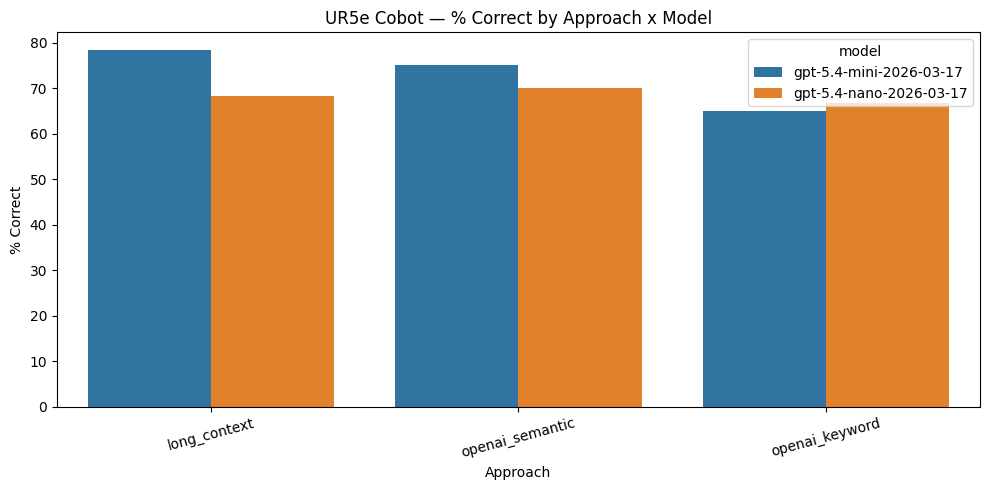

In [13]:
# ------------------------------------------------------------
# 2. Correctness chart: approach x model
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=cobot_perf,
    x="approach",
    y="pct_correct",
    hue="model",
    ax=ax
)

ax.set_title("UR5e Cobot — % Correct by Approach x Model")
ax.set_xlabel("Approach")
ax.set_ylabel("% Correct")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

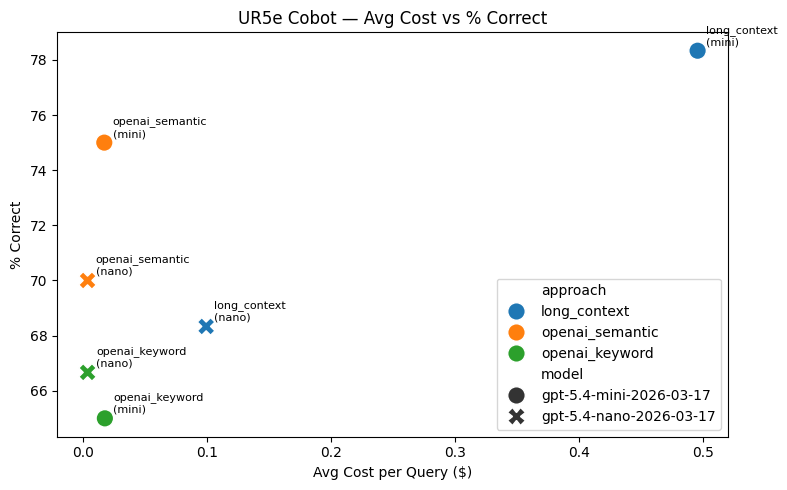

In [14]:
# ------------------------------------------------------------
# 4. Cost vs correctness
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=cobot_perf,
    x="avg_cost",
    y="pct_correct",
    hue="approach",
    style="model",
    s=160,
    ax=ax
)

for _, row in cobot_perf.iterrows():
    model_short = "mini" if "mini" in row["model"].lower() else "nano"
    ax.annotate(
        f"{row['approach']}\n({model_short})",
        (row["avg_cost"], row["pct_correct"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8
    )

ax.set_title("UR5e Cobot — Avg Cost vs % Correct")
ax.set_xlabel("Avg Cost per Query ($)")
ax.set_ylabel("% Correct")

plt.tight_layout()
plt.show()

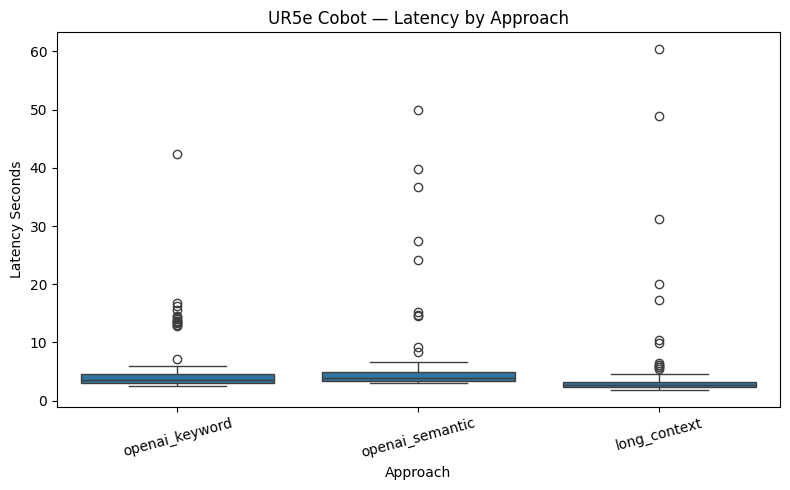

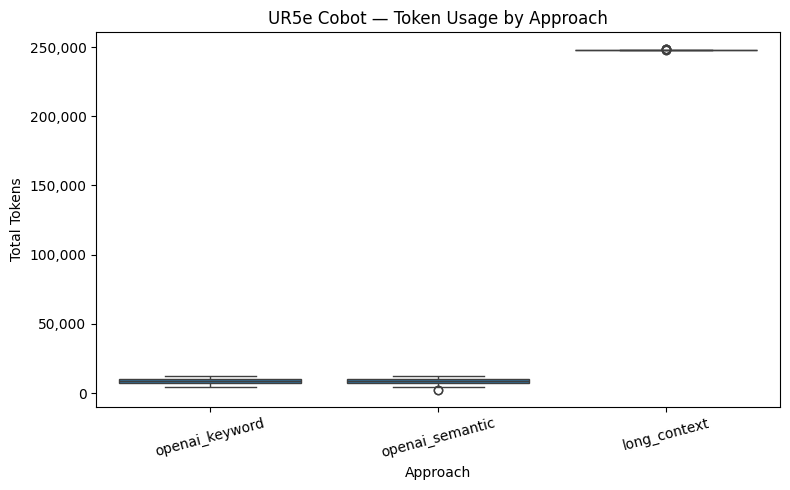

In [15]:
# ------------------------------------------------------------
# 5. Latency and token distribution
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=cobot_df,
    x="approach",
    y="latency_sec",
    ax=ax
)

ax.set_title("UR5e Cobot — Latency by Approach")
ax.set_xlabel("Approach")
ax.set_ylabel("Latency Seconds")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=cobot_df,
    x="approach",
    y="meta_total_tokens",
    ax=ax
)

ax.set_title("UR5e Cobot — Token Usage by Approach")
ax.set_xlabel("Approach")
ax.set_ylabel("Total Tokens")
ax.tick_params(axis="x", rotation=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

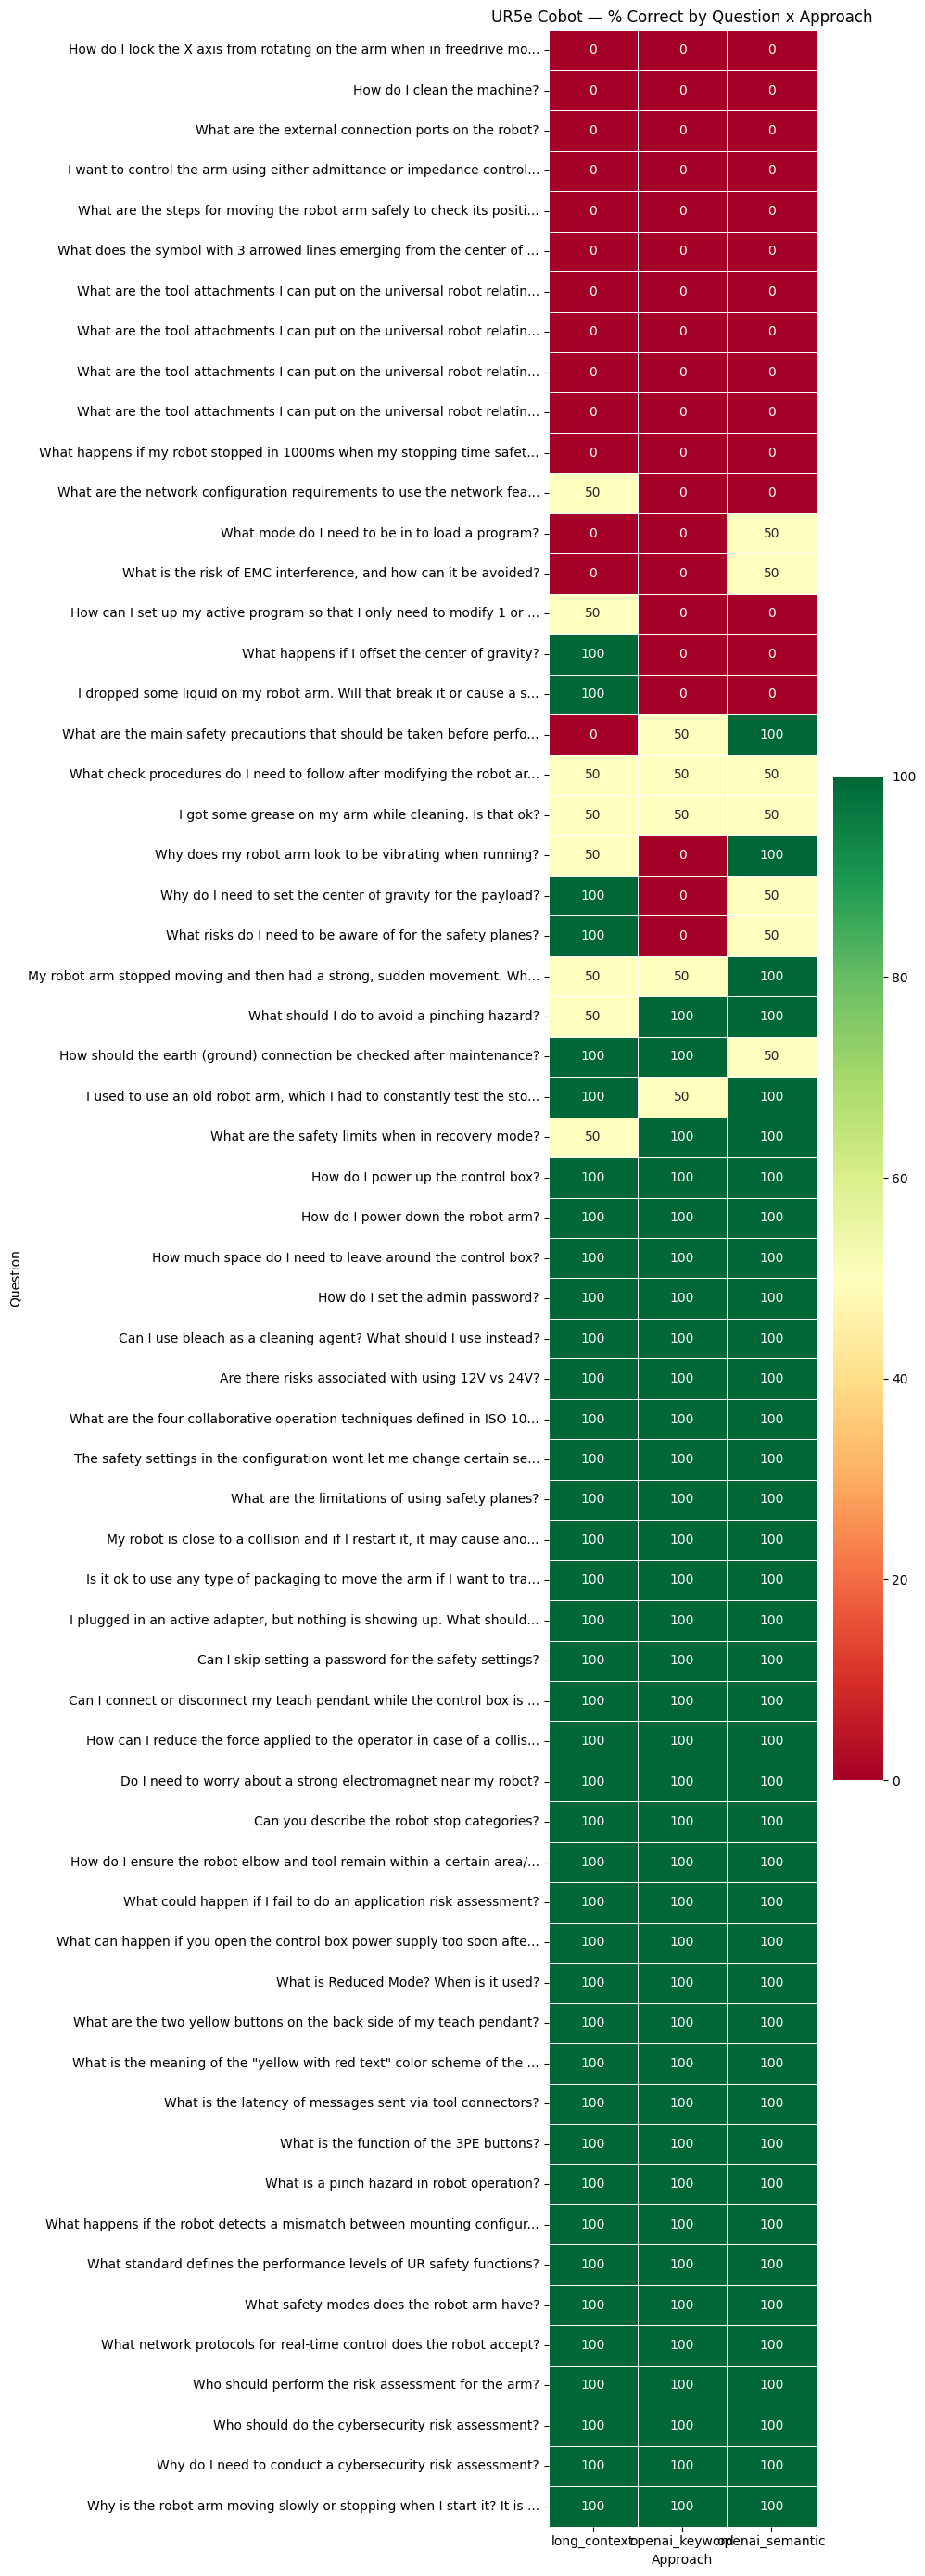

In [16]:
# ------------------------------------------------------------
# 6. Question-level correctness heatmap
# ------------------------------------------------------------

cobot_q_piv = (
    cobot_df
    .groupby(["question", "approach"])["judge_answer_correctness_vs_ref"]
    .mean()
    .unstack("approach") * 100
)

cobot_q_piv.index = cobot_q_piv.index.map(
    lambda q: q[:70] + "..." if len(q) > 70 else q
)

cobot_q_piv = cobot_q_piv.loc[
    cobot_q_piv.mean(axis=1).sort_values().index
]

fig, ax = plt.subplots(figsize=(10, max(8, len(cobot_q_piv) * 0.45)))

sns.heatmap(
    cobot_q_piv,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax
)

ax.set_title("UR5e Cobot — % Correct by Question x Approach")
ax.set_xlabel("Approach")
ax.set_ylabel("Question")

plt.tight_layout()
plt.show()

# UR5e

In [20]:
df.shape

(972, 36)

In [23]:
urf_df = df[df['machine'] == 'UR5e Cobot']

In [24]:
urf_df.shape

(360, 36)

In [ ]:
urf_df

,permutation_id,time_started,time_ended,total_elapsed_time,min_words_for_subsplit,approach,model,max_tokens,reasoning_effort,top_k,...,rougeL,bleu,q,judge_answer_correctness_vs_ref,judge_answer_helpfulness,text_correctness_vs_ref,text_helpfulness,latency_sec,price_usd,machine
0,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:31:29 EDT,2026-04-17 10:31:38 EDT,8.76 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.095238,0.003962,DANGER\r\nDANGER indicates a hazardous situati...,False,False,Correctness: False\n\nStep-by-step reasoning:\...,Relevance: False\n\nStep-by-step reasoning:\n-...,8.76,0.016870,Mill (Bridgeport)
1,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:31:29 EDT,2026-04-17 10:31:35 EDT,5.70 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.171779,0.006596,DANGER(Red with white text)\r\nDANGER indicate...,False,False,Correctness: False\n\nStep-by-step reasoning:\...,Relevance: False\n\nStep-by-step reasoning:\n-...,5.70,0.014984,Mill (Bridgeport)
2,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:31:29 EDT,2026-04-17 10:31:40 EDT,10.55 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.228739,0.066629,There are two tapped holes in the nose cap of ...,False,True,Step-by-step reasoning:\n- Mounting location: ...,Step-by-step reasoning:\n- Identify the questi...,10.55,0.016060,Mill (Bridgeport)
3,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:31:29 EDT,2026-04-17 10:31:34 EDT,5.48 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.294118,0.075962,"No, please do not Use Gas or any other flammab...",True,True,Correctness: True\n\nStep-by-step reasoning:\n...,Relevance: True\n\nStep-by-step reasoning:\n- ...,5.48,0.016446,Mill (Bridgeport)
4,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 10:31:29 EDT,2026-04-17 10:31:37 EDT,8.20 Seconds,3000,openai_keyword,gpt-5.4-mini-2026-03-17,5000,low,3,...,0.307692,0.035078,There is no specified type of cloth to use whe...,True,True,Step-by-step reasoning:\n- The ground truth st...,Relevance: True\n\nStep-by-step reasoning:\n- ...,8.20,0.019850,Mill (Bridgeport)


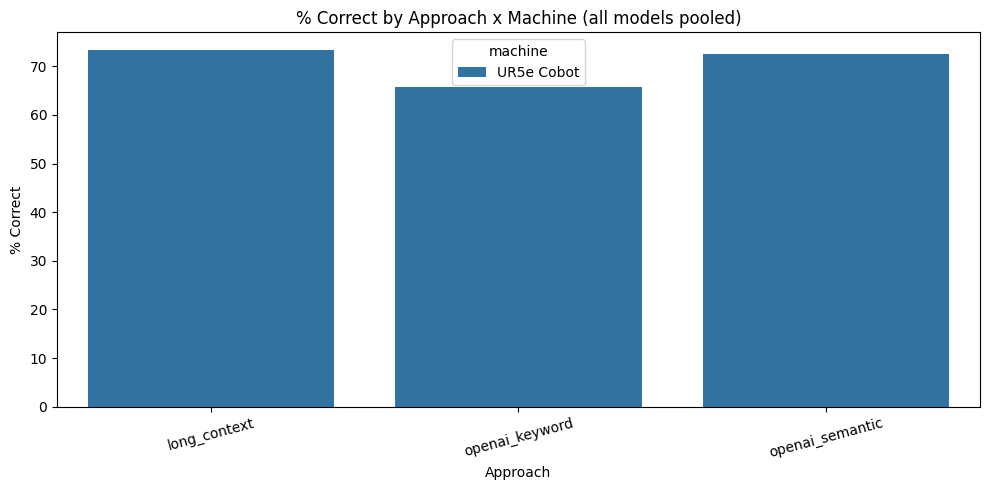

In [28]:
urf_agg = (
    urf_df.groupby(["approach", "machine"])
    .agg(pct_correct=("judge_answer_correctness_vs_ref", lambda x: x.mean() * 100))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=urf_agg, x="approach", y="pct_correct", hue="machine", ax=ax)
ax.set_title("% Correct by Approach x Machine (all models pooled)")
ax.set_xlabel("Approach"); ax.set_ylabel("% Correct")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

In [30]:
urf_df["correct_bool"] = urf_df["judge_answer_correctness_vs_ref"].astype(str).str.lower().map({"true": True, "false": False})

C:\Users\singhr7\AppData\Local\Temp\ipykernel_26404\2381114013.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  urf_df["correct_bool"] = urf_df["judge_answer_correctness_vs_ref"].astype(str).str.lower().map({"true": True, "false": False})


In [ ]:
print(urf_df)

                                        permutation_id  \
102  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
103  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
104  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
105  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
106  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
..                                                 ...   
967  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
968  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
969  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
970  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   
971  eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...   

                time_started               time_ended total_elapsed_time  \
102  2026-04-17 10:35:54 EDT  2026-04-17 10:36:09 EDT      14.38 Seconds   
103  2026-04-17 10:35:54 EDT  2026-04-17 10:35:57 EDT       2.75 Seconds   
104  2026-04-17 10:35:54 EDT  2026-04-17 10:36:07 EDT      13.07 Seconds   

In [34]:
question_summary = (
    urf_df.groupby("question", dropna=False)
    .agg(
        n=("correct_bool", "size"),
        correct=("correct_bool", "sum"),
        avg_correctness=("correct_bool", "mean"),
        avg_cosine=("cosine", "mean"),
        avg_rougeL=("rougeL", "mean"),
        avg_bleu=("bleu", "mean"),
    )
    .reset_index()
    .sort_values(
        ["avg_correctness", "avg_cosine", "avg_rougeL", "avg_bleu", "question"],
        ascending=[True, True, True, True, True],
    )
)

question_summary.head(10)

,question,n,correct,avg_correctness,avg_cosine,avg_rougeL,avg_bleu
25,What are the external connection ports on the ...,6,0,0.000000,0.063795,0.088168,0.006028
32,What are the tool attachments I can put on the...,6,0,0.000000,0.070279,0.075156,0.008791
38,What does the symbol with 3 arrowed lines emer...,6,0,0.000000,0.097719,0.072408,0.005494
33,What are the tool attachments I can put on the...,6,0,0.000000,0.131182,0.065925,0.003567
31,What are the steps for moving the robot arm sa...,6,0,0.000000,0.193667,0.096157,0.006178
40,What happens if my robot stopped in 1000ms whe...,6,0,0.000000,0.212180,0.116384,0.008429
10,How do I lock the X axis from rotating on the ...,6,0,0.000000,0.274847,0.172096,0.008764
20,I want to control the arm using either admitta...,6,0,0.000000,0.307892,0.181241,0.015771
8,How do I clean the machine?,6,0,0.000000,0.333907,0.168626,0.014592
47,"What is the risk of EMC interference, and how ...",6,1,0.166667,0.098103,0.068602,0.004159


9 questions were completetly unanswered. 

In [39]:
# Aggregate one row per (question, approach) — now grabbing judge reasoning too
pivot_df = (
    urf_df
    .groupby(["question", "approach"])
    .agg(
        generated_answer=("generated_answer", "first"),
        judge_reasoning=("text_correctness_vs_ref", "first"),
        avg_correctness=("correct_bool", "mean"),
    )
    .reset_index()
)

# Wide pivots for each field
answers_wide = pivot_df.pivot(
    index="question", columns="approach", values="generated_answer"
).rename(columns={
    "long_context": "answer_long",
    "openai_semantic": "answer_semantic",
    "openai_keyword": "answer_keyword",
})

judge_wide = pivot_df.pivot(
    index="question", columns="approach", values="judge_reasoning"
).rename(columns={
    "long_context": "judge_long",
    "openai_semantic": "judge_semantic",
    "openai_keyword": "judge_keyword",
})

correct_wide = pivot_df.pivot(
    index="question", columns="approach", values="avg_correctness"
).add_prefix("correct_")

gold = urf_df.groupby("question")["gold_answer"].first()

final = (
    pd.concat([gold, answers_wide, judge_wide, correct_wide], axis=1)
    .reset_index()
)

# Filter to universally missed
missed = final[
    (final["correct_long_context"] == 0)
    & (final["correct_openai_semantic"] == 0)
    & (final["correct_openai_keyword"] == 0)
]

print(f"Universally missed: {len(missed)}")

Universally missed: 9


In [40]:
missed

,question,gold_answer,answer_long,answer_keyword,answer_semantic,judge_long,judge_keyword,judge_semantic,correct_long_context,correct_openai_keyword,correct_openai_semantic
8,How do I clean the machine?,Prepare the surface by removing loose dirt or ...,Thoroughly clean the protective coating from t...,Thoroughly clean the protective coating from t...,Thoroughly clean the protective coating from t...,Correctness: False\n\nStep-by-step reasoning:\...,Correctness: False\n\nStep-by-step reasoning:\...,Correctness: False\n\nStep-by-step reasoning:\...,0.0,0.0,0.0
10,How do I lock the X axis from rotating on the ...,"On the freedrive pane, there are toggles to lo...","In Freedrive, use the Freedrive panel and sele...","In the Freedrive panel, select **Translation**...","In Freedrive, use the Freedrive panel and sele...",Correctness: False\n\nStep-by-step reasoning:\...,Correctness: False\n\nStep-by-step reasoning:\...,Reasoning:\n- The question is specifically abo...,0.0,0.0,0.0
20,I want to control the arm using either admitta...,"Yes, admittance and impendance control schemes...",It cannot be determined from the provided docu...,It cannot be determined from the provided docu...,It cannot be determined from the provided docu...,Correctness: False\n\nStep-by-step reasoning:\...,Correctness: False\n\nStep-by-step reasoning:\...,Correctness: False\n\nStep-by-step reasoning:\...,0.0,0.0,0.0
25,What are the external connection ports on the ...,"Teach Pendant Port, SD Card slot, Ethernet, US...",The robot’s external connection ports are on t...,The Control Box underside has external connect...,The underside of the I/O interface groups is e...,Correctness: False\n\nStep-by-step reasoning:\...,Correctness: False\n\nStep-by-step reasoning:\...,Correctness: False\n\nStep-by-step reasoning:\...,0.0,0.0,0.0
31,What are the steps for moving the robot arm sa...,"Move to zero position, disconnect power, inspe...","To check position stability, first move the ro...","To move the robot arm safely, use the **Move t...","To move the robot arm safely, use the **Move T...",Correctness: False\n\nStep-by-step reasoning:\...,Correctness: False\n\nStep-by-step reasoning:\...,Step-by-step reasoning:\n- The expected steps ...,0.0,0.0,0.0
32,What are the tool attachments I can put on the...,"Many kinds of grippers such as parallel, three...",The manual says the robot is intended to handl...,The documentation says you can attach an end e...,"You can attach an end effector, also called a ...",Step-by-step reasoning:\n- The question asks s...,Correctness: False\n\nReasoning:\n- The ground...,Correctness: False\n\nStep-by-step reasoning:\...,0.0,0.0,0.0
33,What are the tool attachments I can put on the...,Welding and arc welding attatchments.,The robot can use a tool/end effector attached...,"The documentation says an end effector, also c...","The documentation says an end effector, also c...",Correctness: False\n\nStep-by-step reasoning:\...,Step-by-step reasoning:\n- The question asks f...,Correctness: False\n\nReasoning:\n- The ground...,0.0,0.0,0.0
38,What does the symbol with 3 arrowed lines emer...,This is a icon used for the translation contro...,I can’t determine which symbol you mean from t...,The meaning of that symbol cannot be determine...,The provided documents only state that the **P...,Correctness: False\n\nStep-by-step reasoning:\...,Step-by-step reasoning:\n- The question asks f...,Correctness: False\n\nReasoning:\n- The ground...,0.0,0.0,0.0
40,What happens if my robot stopped in 1000ms whe...,The robot arm will enter recovery mode because...,If the stopping time safety limit is set to 20...,If the robot’s stopping time exceeds the confi...,If the robot takes 1000 ms to stop and the Sto...,Correctness: False\n\nStep-by-step reasoning:\...,Correctness: False\n\nStep-by-step reasoning:\...,Step-by-step reasoning:\n- The scenario descri...,0.0,0.0,0.0


# Question 1 

In [43]:
row = missed.iloc[0]
print("=" * 90)
print(f"Q: {row['question']}\n")
print(f"GOLD:\n{row['gold_answer']}\n")
print("-" * 90)
for approach in ["long", "semantic", "keyword"]:
    print(f"\n[{approach.upper()}] ANSWER:")
    print(row[f"answer_{approach}"])
    print(f"\n[{approach.upper()}] JUDGE:")
    print(row[f"judge_{approach}"])
    print()

Q: How do I clean the machine?

GOLD:
Prepare the surface by removing loose dirt or debris. Apply a cleaning agent to the surface that needs cleaning, agitater the agent for stubborn spots, let the agent rest on the surface for 5 minutes, rinse the system with water, and leave the machine out to air dry, or dry using towels.

------------------------------------------------------------------------------------------

[LONG] ANSWER:
Thoroughly clean the protective coating from the machine with a suitable cleaning solution, and do not use gasoline or any other flammable cleaning agent. After initial cleaning, move the table, saddle, and knee by hand to the limit stops, then clean and lubricate the exposed ways; also loosen the ram bolts and move the ram forward and backward to clean and lubricate it. Do not move movable parts until all ways have been well cleaned and lubricated. [Mill (Bridgeport)]

[LONG] JUDGE:
Correctness: False

Step-by-step reasoning:
- The ground truth specifies a c

Ambiguious Question
The core problem: the question is ambiguous and the gold answer doesn't match the manual. This is also a systems issue, we need the user to specify what machine to get. 

The question "How do I clean the machine?" is being asked in a multi-machine corpus (UR5e Cobot is the labeled machine, but the retrievals are pulling from Bridgeport mill chapters too). 

- Long & Keyword → pulled from 006__L1__Chapter_1_-_Installation (Bridgeport mill installation, talks about cleaning protective coating off a new machine)
- Semantic → pulled both the Bridgeport installation passage AND the UR5e maintenance chapter (cloth + isopropyl/ethanol/naphtha)

Issues and rectifications:

- Recheck the gold and question and make sure it is correct. Seems like it may not be right.  
- The question is under-specified. Needs a referrant
- 2 solutions 
    - In the prompt, ask the agent to ask the user to specify which machine
    - Tighten Vector Search using SQL like commands to filter on metadata. https://developers.openai.com/api/reference/resources/vector_stores/methods/search

# Question 2 

In [44]:
row = missed.iloc[1]
print("=" * 90)
print(f"Q: {row['question']}\n")
print(f"GOLD:\n{row['gold_answer']}\n")
print("-" * 90)
for approach in ["long", "semantic", "keyword"]:
    print(f"\n[{approach.upper()}] ANSWER:")
    print(row[f"answer_{approach}"])
    print(f"\n[{approach.upper()}] JUDGE:")
    print(row[f"judge_{approach}"])
    print()

Q: How do I lock the X axis from rotating on the arm when in freedrive mode?

GOLD:
On the freedrive pane, there are toggles to lock X, Y, Z, and RX, RY, and RZ axes. To lock the rotational X axis you should toggle off the RX option.

------------------------------------------------------------------------------------------

[LONG] ANSWER:
In Freedrive, use the Freedrive panel and select **Translation** to allow movement through all axes **without rotation**. If you want movement only in a plane, select **Plane** instead. [UR5e Cobot]

[LONG] JUDGE:
Correctness: False

Step-by-step reasoning:
- The ground truth specifies that in the Freedrive pane there are individual toggles for X, Y, Z, and RX, RY, RZ, and to lock the rotational X axis specifically, you should toggle off RX.
- The student answer does not mention the RX toggle or per-axis locking. Instead, it suggests selecting "Translation" to allow movement without any rotation, which would disable all rotational axes, not just RX.


Interesting, we get alomost identical answers, seems like there is a grouning issue. 

That chunk describes Freedrive's movement modes

Issues and rectifications:
- Check the reterived docs and figure out what is happening. 
- I don't know the machine well enough to figure out what is happening. 



Page 52


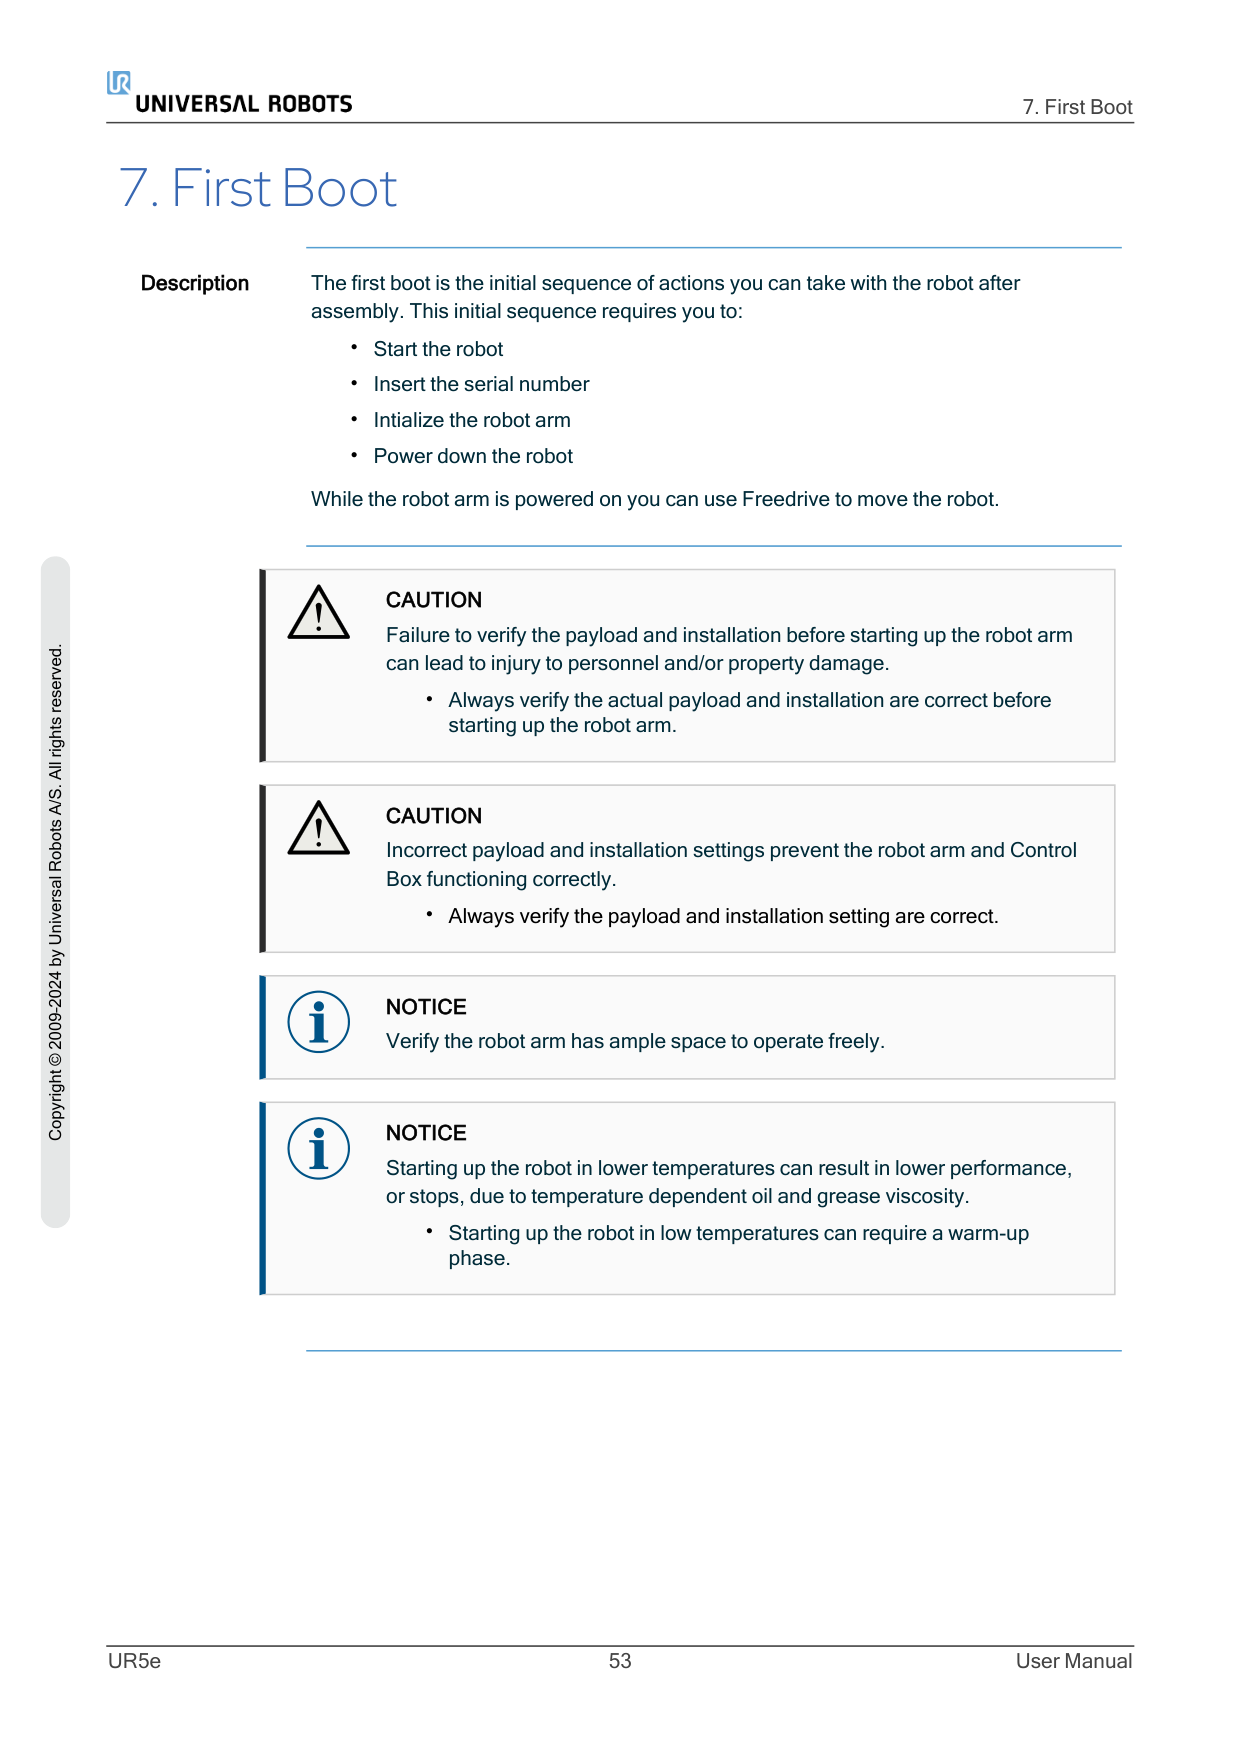


Page 53


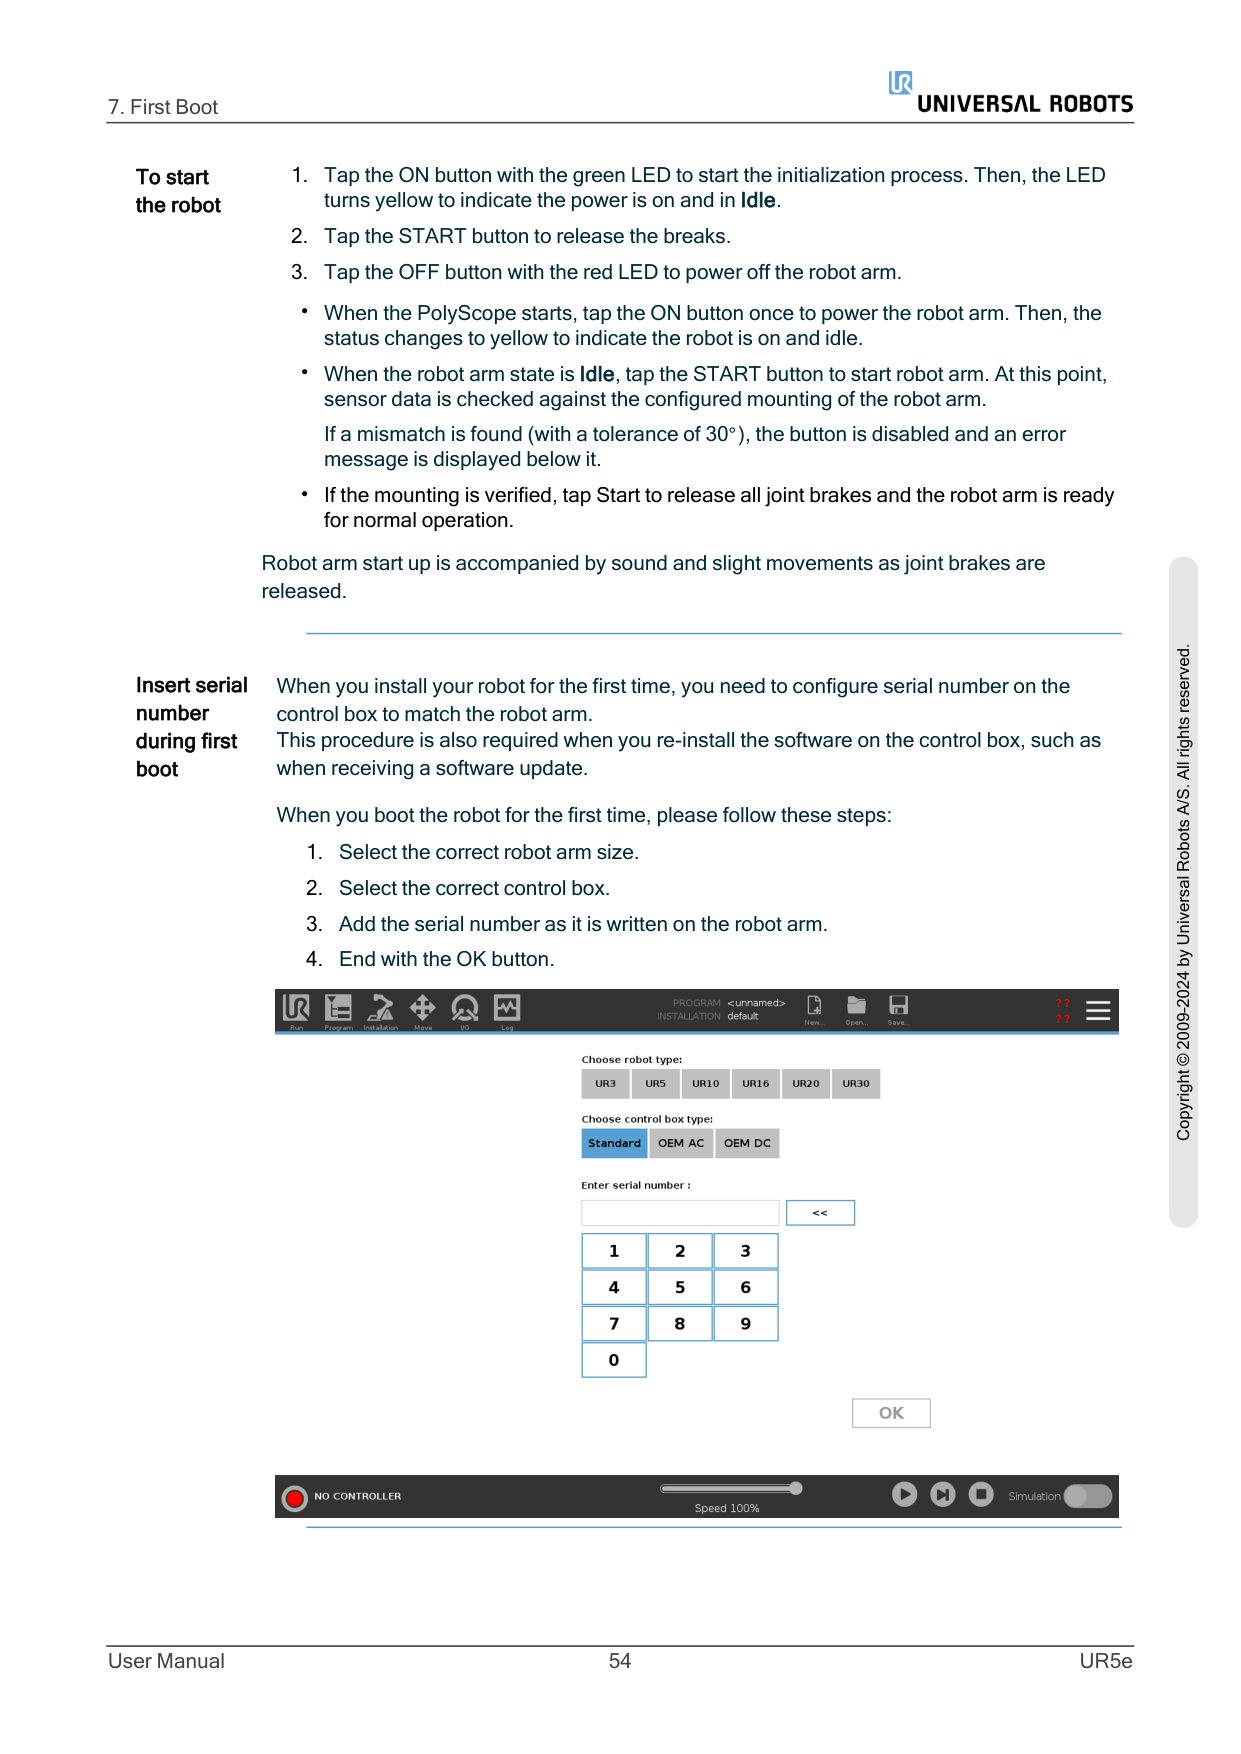


Page 54


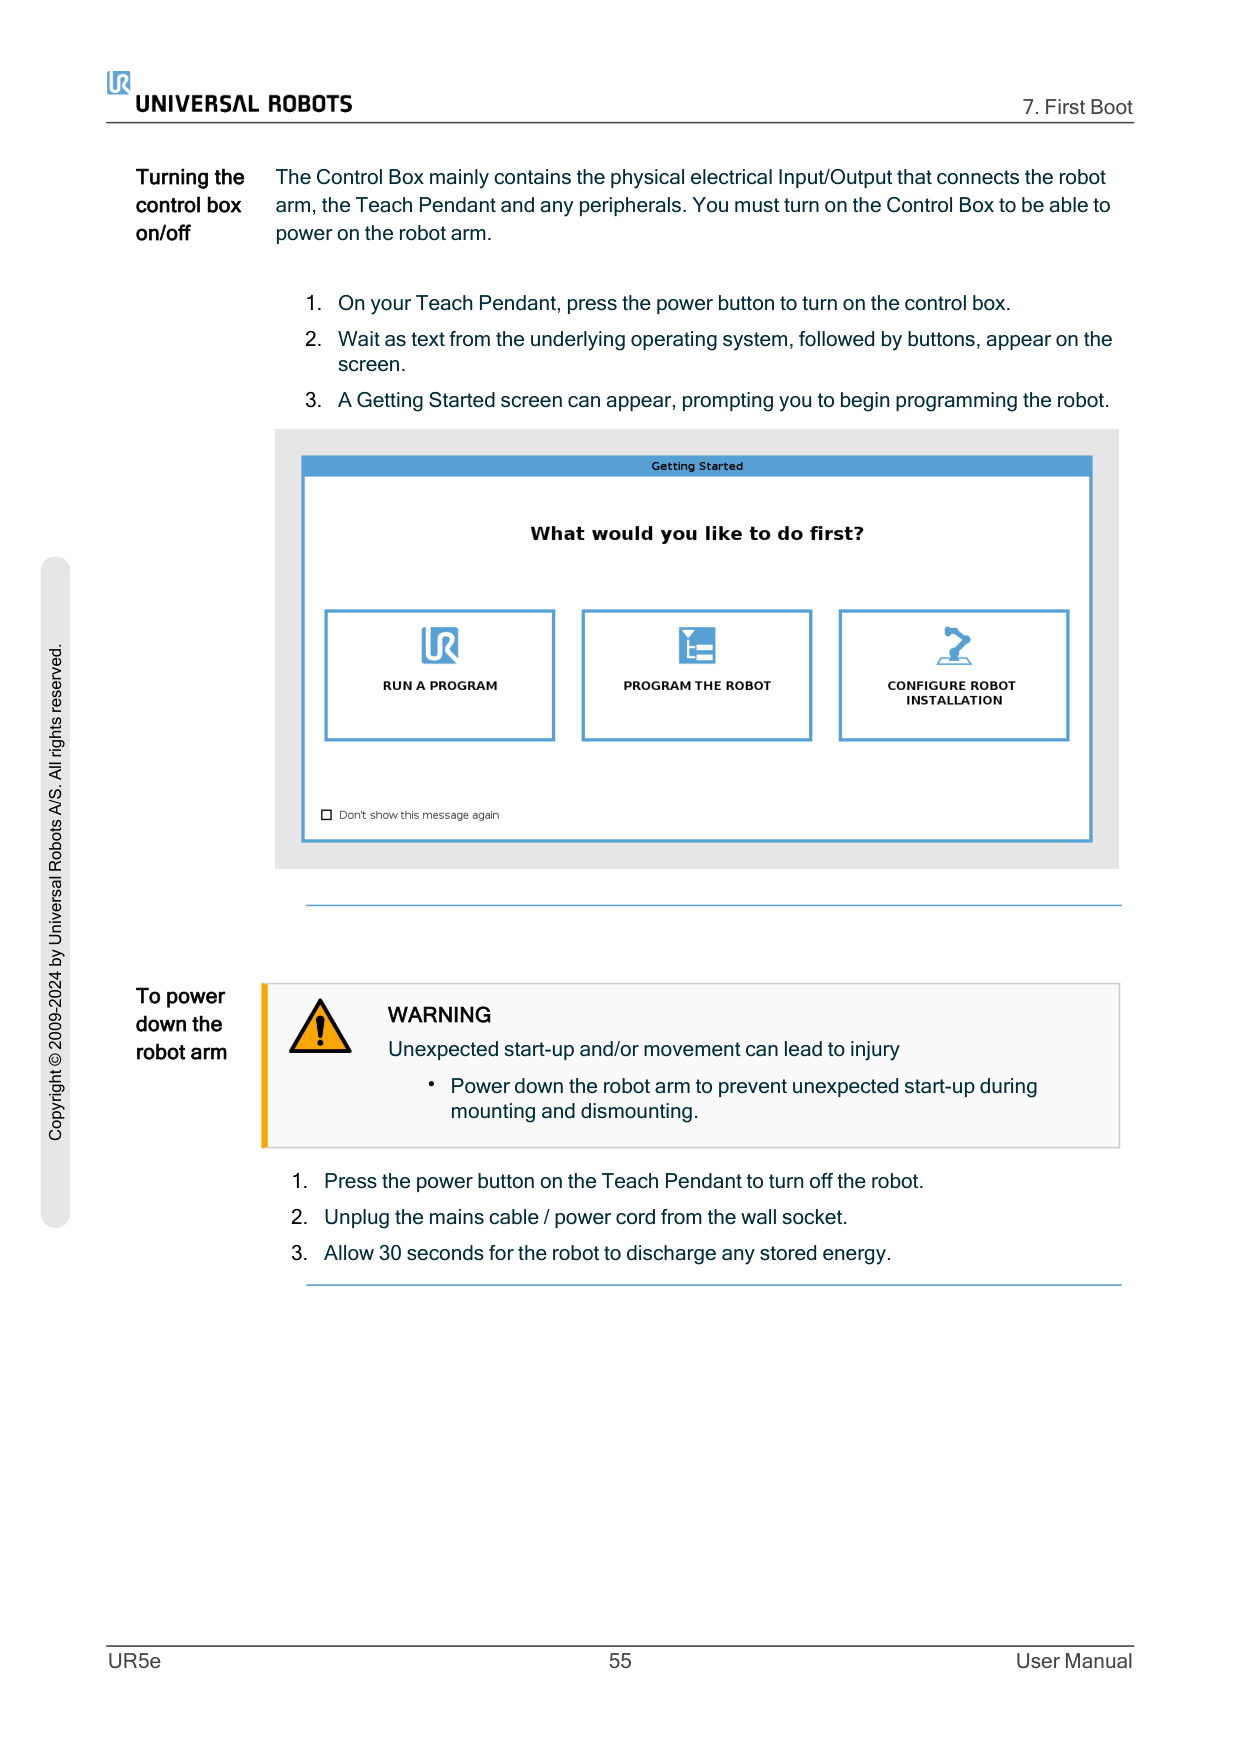


Page 55


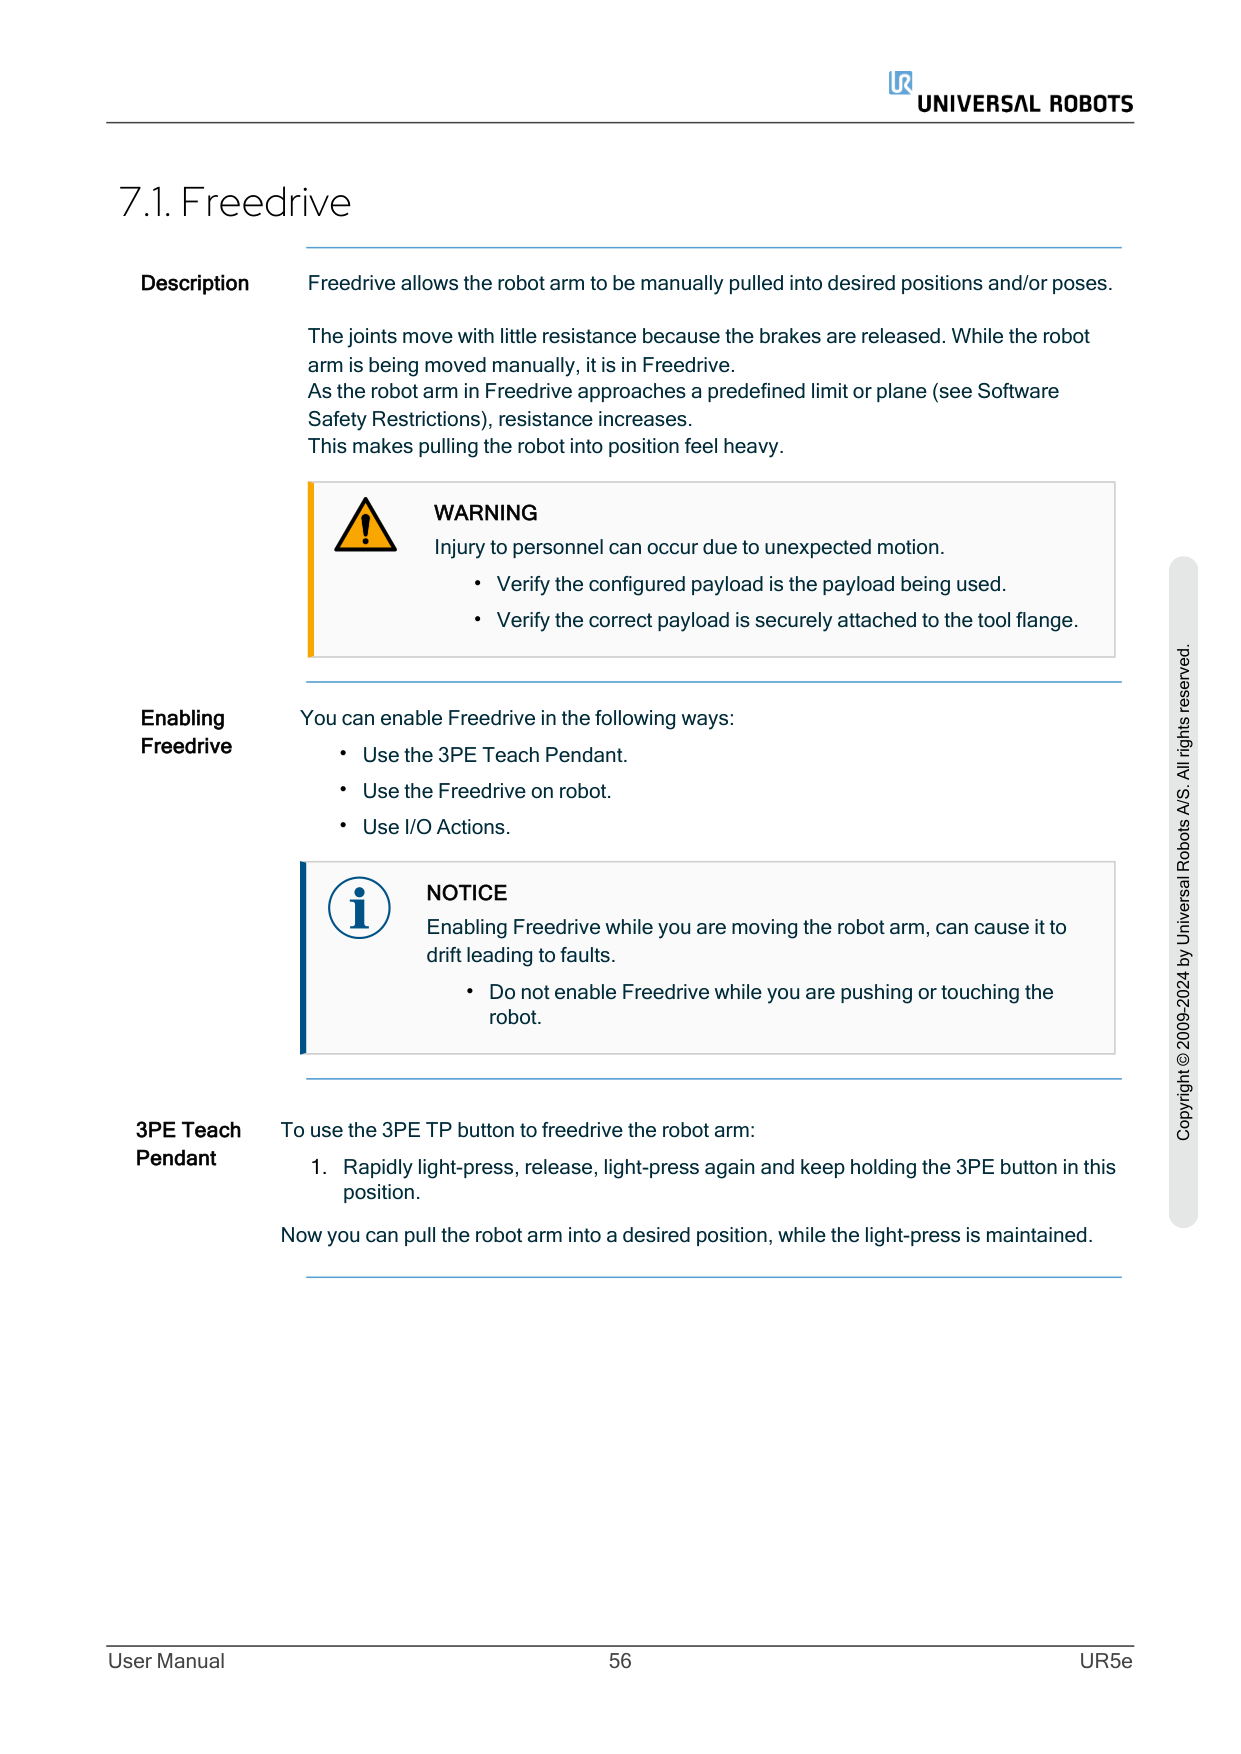


Page 56


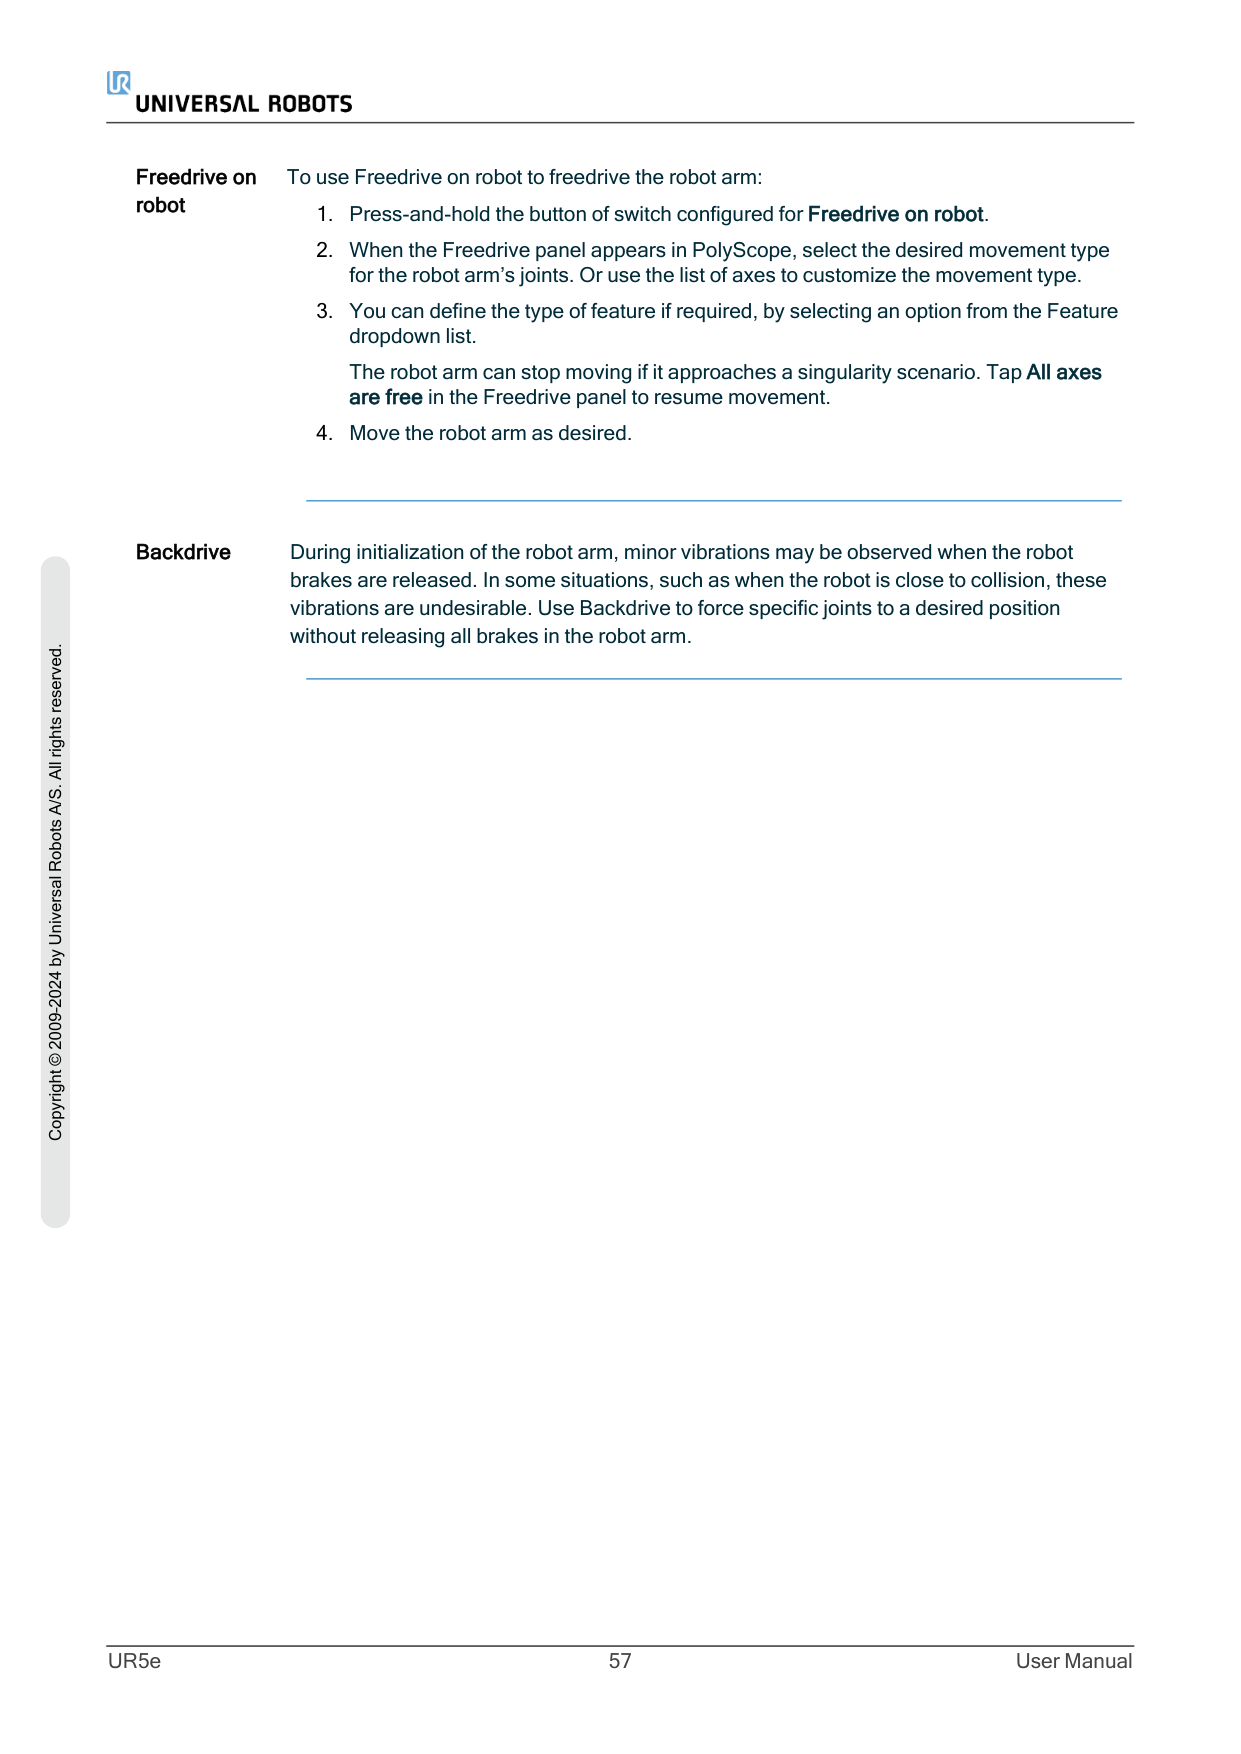


Page 57


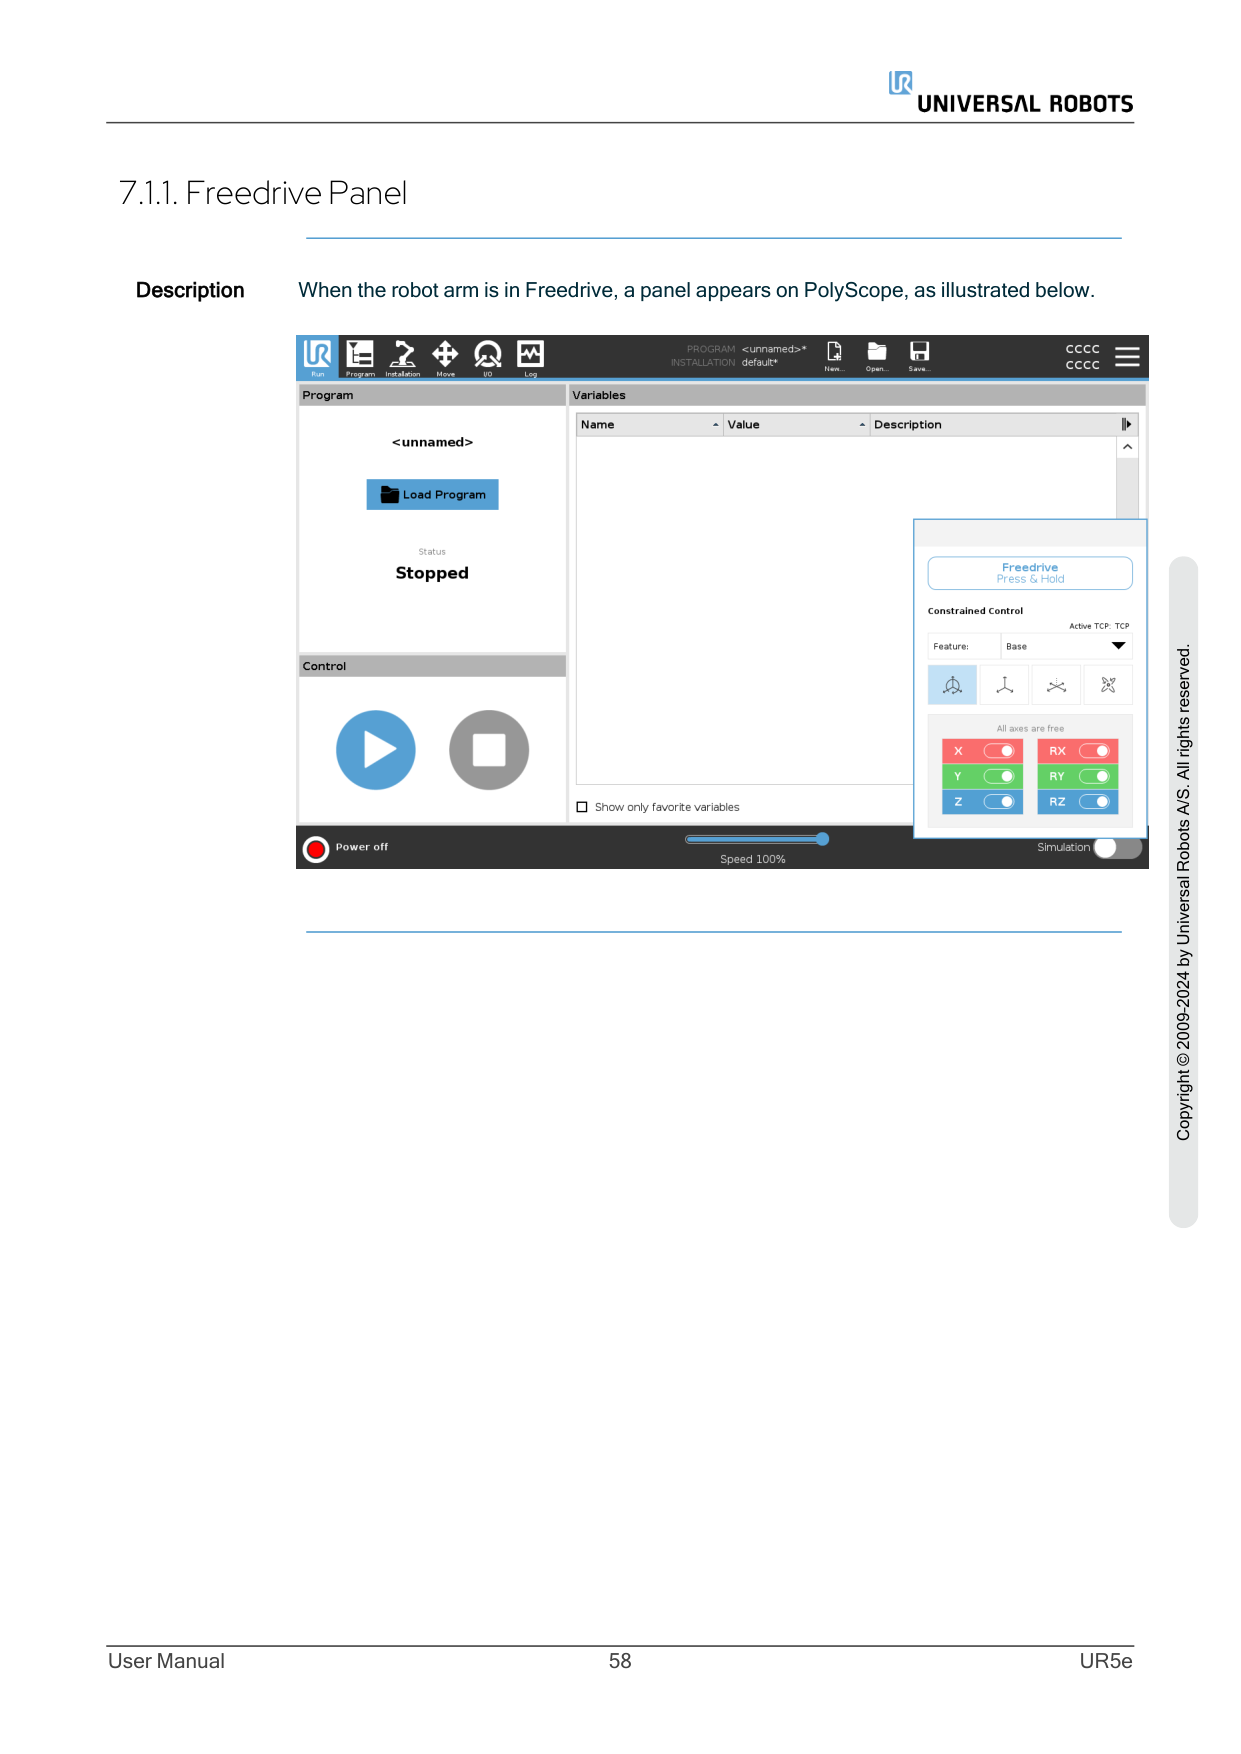


Page 58


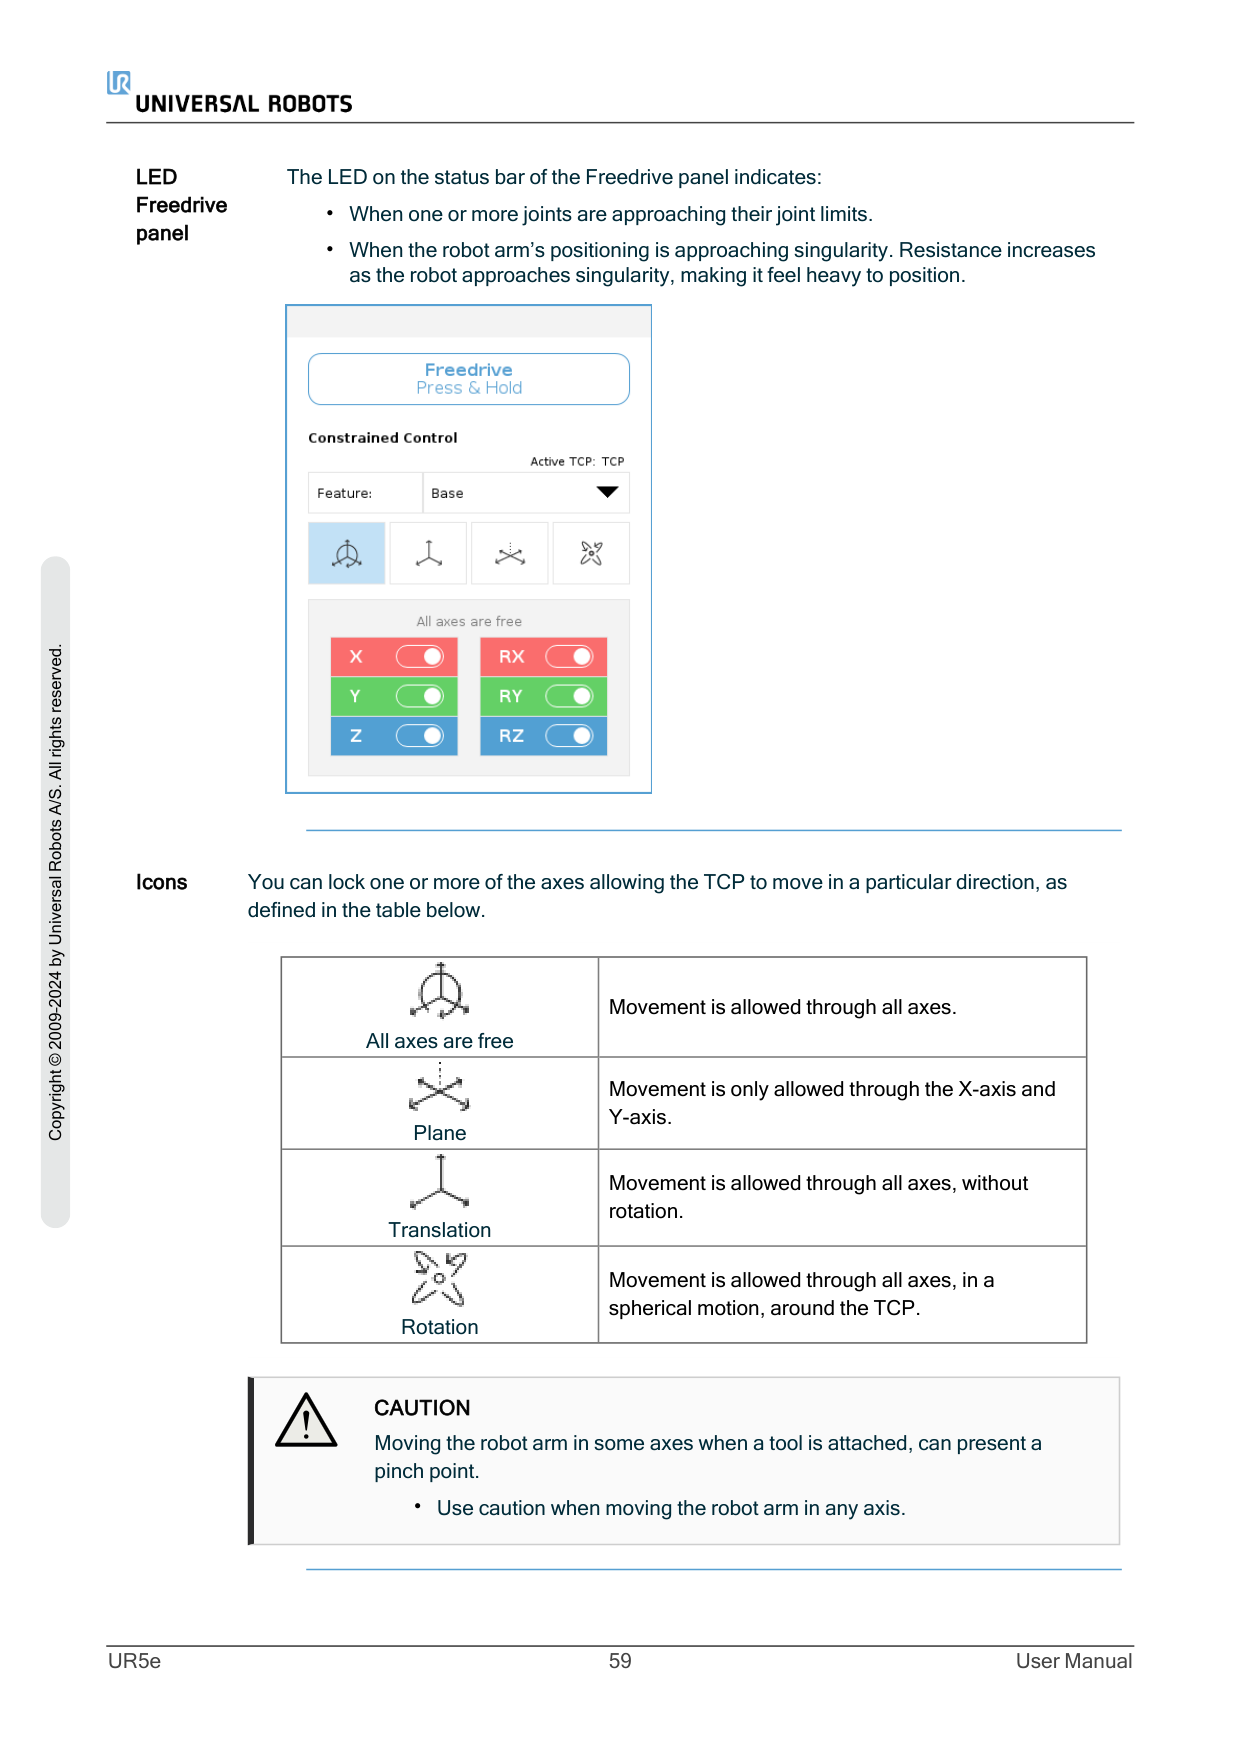

In [57]:
import fitz  # PyMuPDF
from pathlib import Path
from IPython.display import Image, display

PDF_DIR = Path("../data/input/input_pdfs")
UR5E_PDF = PDF_DIR / "UR5e_Universal_Robots User Manual.pdf"

def show_pdf_pages(pdf_path, page_numbers, dpi=150):
    """Render specific pages of a PDF as images and display inline."""
    doc = fitz.open(pdf_path)
    for page_num in page_numbers:
        # PyMuPDF is 0-indexed; page 52 in the manual = index 51
        page = doc[page_num - 1]
        pix = page.get_pixmap(dpi=dpi)
        img_bytes = pix.tobytes("png")
        print(f"\n{'='*80}\nPage {page_num}\n{'='*80}")
        display(Image(data=img_bytes))
    doc.close()

# Show pages 52-58 from the chunk that all 3 approaches retrieved
show_pdf_pages(UR5E_PDF, range(52, 59))

# Question 3 

In [58]:
row = missed.iloc[2]
print("=" * 90)
print(f"Q: {row['question']}\n")
print(f"GOLD:\n{row['gold_answer']}\n")
print("-" * 90)
for approach in ["long", "semantic", "keyword"]:
    print(f"\n[{approach.upper()}] ANSWER:")
    print(row[f"answer_{approach}"])
    print(f"\n[{approach.upper()}] JUDGE:")
    print(row[f"judge_{approach}"])
    print()

Q: I want to control the arm using either admittance or impedance control schemes by reading joint positions/torques and commanding joint velocities/torques at a high rate. Can this be implemented using the standard hardware and controller?

GOLD:
Yes, admittance and impendance control schemes can be implemented using standard and controler, but it would require a controller with direct torque control or low-level research API to command the velocities the fastest rate for UR robots is 125 Hz

------------------------------------------------------------------------------------------

[LONG] ANSWER:
It cannot be determined from the provided documents whether the standard hardware and controller support implementing admittance or impedance control by reading joint positions/torques and commanding joint velocities/torques at a high rate. The sources describe available safety I/O, fieldbus options, and robot programming interfaces, but they do not state that this type of high-rate joint to

In [62]:
ur5e_text = cropped_texts["UR5e Cobot"]

# Look for the gold's specific terms
patterns = {
    "admittance":           r'\badmittance\b',
    "impedance":            r'\bimpedance\b',
    "125 Hz":               r'125\s*Hz',

    "research API":         r'research\s+API',

}

for label, pat in patterns.items():
    matches = list(re.finditer(pat, ur5e_text, re.IGNORECASE))
    print(f"\n[{label}] — {len(matches)} hits")
    for m in matches[:2]:
        start = max(0, m.start() - 80)
        end = min(len(ur5e_text), m.end() + 120)
        snippet = ur5e_text[start:end].replace('\n', ' ')
        print(f"  ...{snippet}...")


[admittance] — 0 hits

[impedance] — 0 hits

[125 Hz] — 0 hits

[research API] — 0 hits


I want to know where this gold answer comes from. It may be out of scope for corpus

All three approaches did the right thing. They retrieved what the manual does say (PolyScope tabs, safety functions, the 500 Hz internal rate)

# Question 4 

In [63]:
row = missed.iloc[3]
print("=" * 90)
print(f"Q: {row['question']}\n")
print(f"GOLD:\n{row['gold_answer']}\n")
print("-" * 90)
for approach in ["long", "semantic", "keyword"]:
    print(f"\n[{approach.upper()}] ANSWER:")
    print(row[f"answer_{approach}"])
    print(f"\n[{approach.upper()}] JUDGE:")
    print(row[f"judge_{approach}"])
    print()

Q: What are the external connection ports on the robot?

GOLD:
Teach Pendant Port, SD Card slot, Ethernet, USB 2.0 and USB 3.0, Mini Displayport, 10A Mini Blade Fuse

------------------------------------------------------------------------------------------

[LONG] ANSWER:
The robot’s external connection ports are on the underside of the Control Box I/O interface groups, with capped openings at the base of the cabinet for routing external connector cables. The manual also notes a Mini DisplayPort for monitors, an Ethernet port for network/fieldbus connections, and internal controller I/O for safety, digital, analog, and configurable signals. [UR5e Cobot]

[LONG] JUDGE:
Correctness: False

Step-by-step reasoning:
- The ground truth specifies a list of external connection ports: Teach Pendant Port, SD Card slot, Ethernet, USB 2.0 and USB 3.0, Mini DisplayPort, and a 10A Mini Blade Fuse.
- The student answer only explicitly identifies two of these: Mini DisplayPort and Ethernet.
- It omit

In [64]:
import re

ur5e_text = cropped_texts["UR5e Cobot"]

# Look for each gold term individually in the full corpus
gold_terms = {
    "Teach Pendant":    r'teach\s+pendant',
    "SD Card":          r'SD\s+card',
    "USB 2.0":          r'USB\s*2\.0',
    "USB 3.0":          r'USB\s*3\.0',
    "Mini DisplayPort": r'mini\s+displayport',
    "10A":              r'10\s*A\b',
    "Mini Blade Fuse":  r'mini\s+blade\s+fuse',
    "Ethernet":         r'\bethernet\b',
}

for label, pat in gold_terms.items():
    matches = list(re.finditer(pat, ur5e_text, re.IGNORECASE))
    print(f"\n[{label}] — {len(matches)} hits")
    for m in matches[:2]:
        start = max(0, m.start() - 80)
        end = min(len(ur5e_text), m.end() + 120)
        snippet = ur5e_text[start:end].replace('\n', ' ')
        print(f"  ...{snippet}...")


[Teach Pendant] — 111 hits
  ...essment 34 4.1. Pinch Hazard 36 5. Lifting and Handling 38 5.1. Control Box and Teach Pendant 38 5.2. Robot Arm 38 6. Assembly 39 6.1. Workspace and Operating Space 40 6.2. Dimensioning the Stand 41 6.3. Mounting ...
  ... Control Box Connection Ports 72 8.3.1. Ethernet 73 8.4. Controller I/O 74 8.5. Teach Pendant with 3-Position Enabling Device 76 8.5.1. 3PE Teach Pendant Installation 78 8.5.2. 3PE Teach Pendant Button Functions 8...

[SD Card] — 1 hits
  ...To ensure secure removal of highly sensitive data, securely wipe or destroy the SD card. For information about setting an admin password and local port forwarding, see the Hamburger Menu. You can also read S...

[USB 2.0] — 0 hits

[USB 3.0] — 0 hits

[Mini DisplayPort] — 1 hits
  ...un external connector cables to access the ports. External connection ports The Mini Displayport supports monitors using Displayport. This requires an active Mini Display to DVI or HDMI converter. Passive converters ..


Page 71


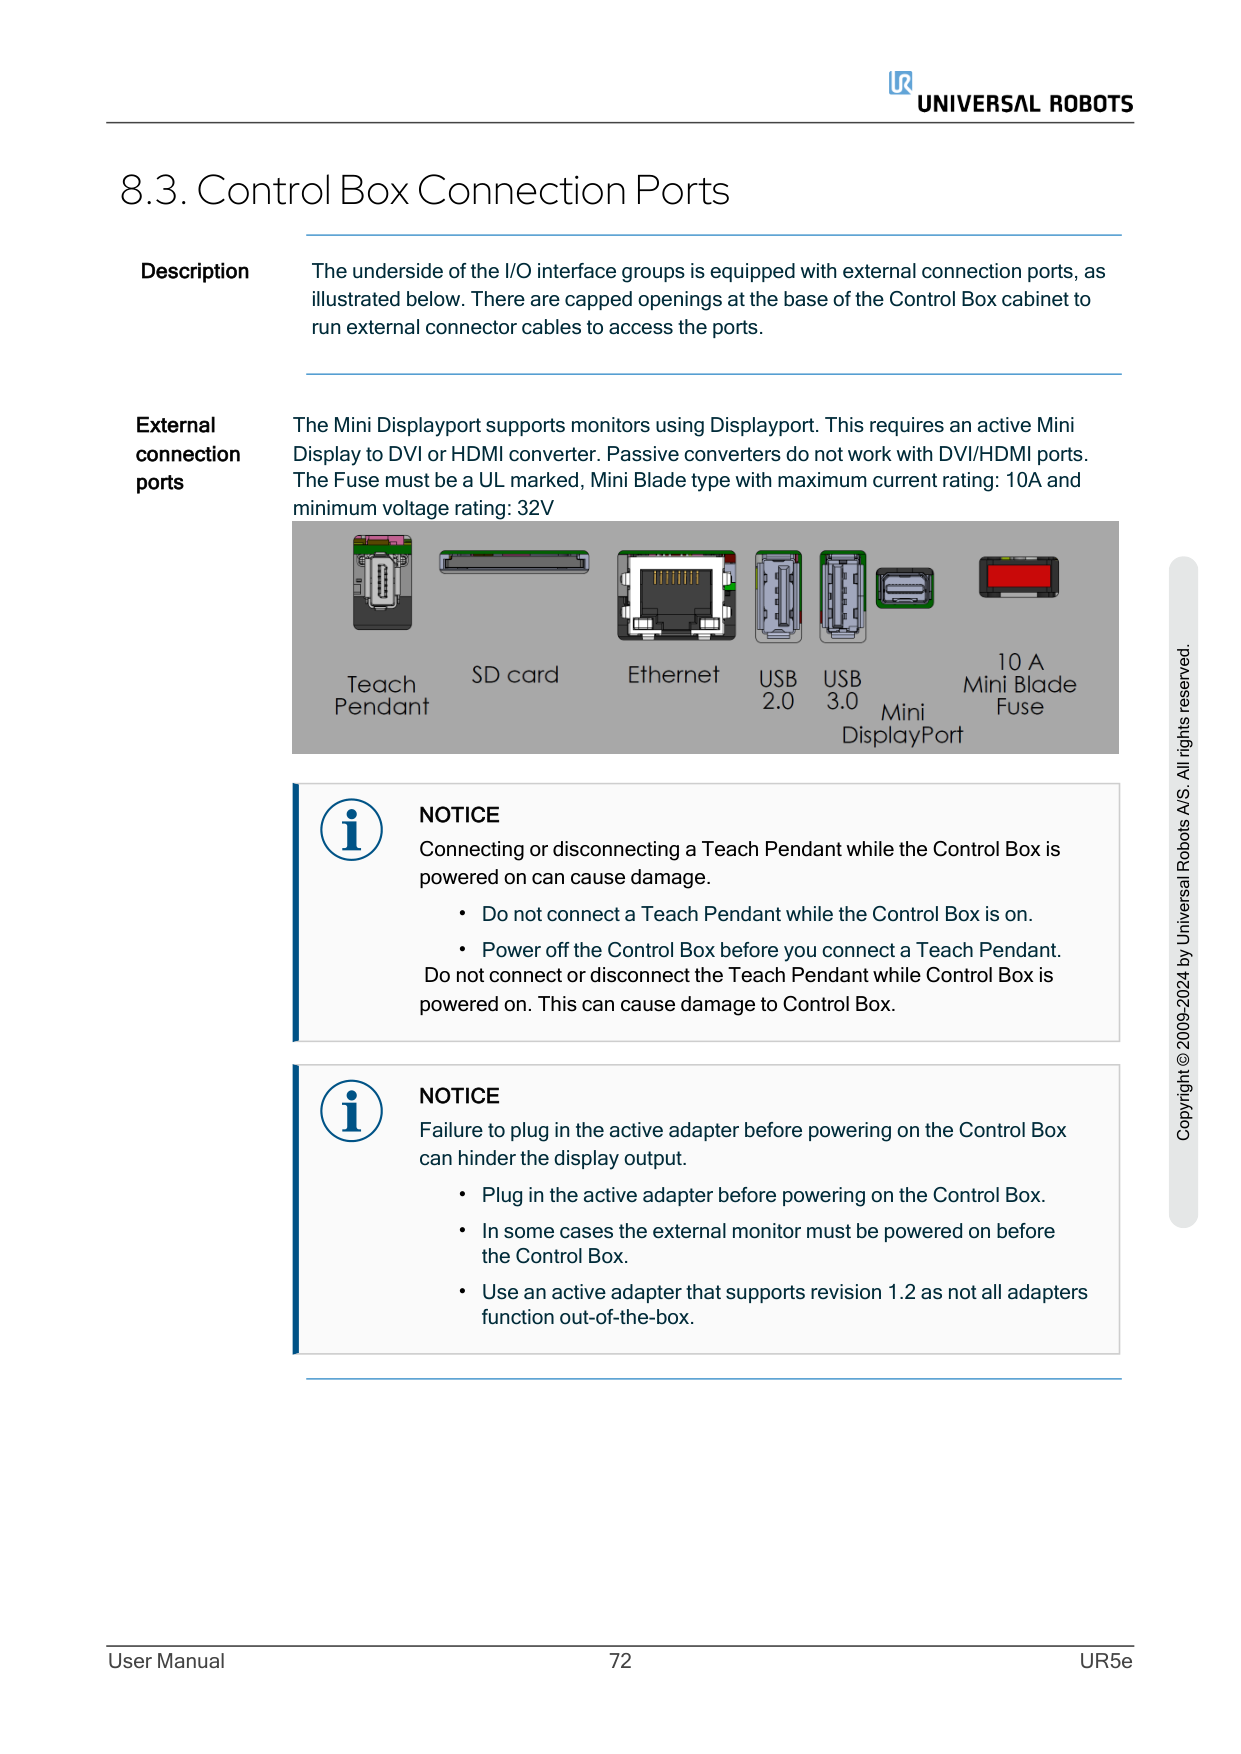

In [65]:
import fitz  # PyMuPDF
from pathlib import Path
from IPython.display import Image, display

PDF_DIR = Path("../data/input/input_pdfs")
UR5E_PDF = PDF_DIR / "UR5e_Universal_Robots User Manual.pdf"

def show_pdf_pages(pdf_path, page_numbers, dpi=150):
    """Render specific pages of a PDF as images and display inline."""
    doc = fitz.open(pdf_path)
    for page_num in page_numbers:
        # PyMuPDF is 0-indexed; page 52 in the manual = index 51
        page = doc[page_num - 1]
        pix = page.get_pixmap(dpi=dpi)
        img_bytes = pix.tobytes("png")
        print(f"\n{'='*80}\nPage {page_num}\n{'='*80}")
        display(Image(data=img_bytes))
    doc.close()

# Show pages 52-58 from the chunk that all 3 approaches retrieved
show_pdf_pages(UR5E_PDF, range(71, 72))

This is an edge of the model. The gold is a clear syenthesized list, what I would expect from an expert. The information is clearly in an image

Solutions

Run OCR and create descriptions of images. Lot of potential solutions, need to ask Arthur on the way forward. 


In [66]:
row = missed.iloc[4]
print("=" * 90)
print(f"Q: {row['question']}\n")
print(f"GOLD:\n{row['gold_answer']}\n")
print("-" * 90)
for approach in ["long", "semantic", "keyword"]:
    print(f"\n[{approach.upper()}] ANSWER:")
    print(row[f"answer_{approach}"])
    print(f"\n[{approach.upper()}] JUDGE:")
    print(row[f"judge_{approach}"])
    print()

Q: What are the steps for moving the robot arm safely to check its position stability?

GOLD:
Move to zero position, disconnect power, inspect cables and bolts, use Freedrive to test hold.

------------------------------------------------------------------------------------------

[LONG] ANSWER:
To check position stability, first move the robot arm to ZERO position if possible, then turn off and disconnect the power cable from the Control Box. Unmount any tool or attachment, or set the TCP/Payload/CoG according to the tool specifications, then use Freedrive to pull/push the robot into a horizontally elongated position and release it to verify it can maintain the position without support. [UR5e Cobot]

[LONG] JUDGE:
Correctness: False

Step-by-step reasoning:
- The ground truth requires four steps: move to zero, disconnect power, inspect cables and bolts, and use Freedrive to test hold.
- The student includes moving to zero and disconnecting power, and they do include a Freedrive-based 

# Questionn 5 

In [68]:
row = missed.iloc[4]
print("=" * 90)
print(f"Q: {row['question']}\n")
print(f"GOLD:\n{row['gold_answer']}\n")
print("-" * 90)
for approach in ["long", "semantic", "keyword"]:
    print(f"\n[{approach.upper()}] ANSWER:")
    print(row[f"answer_{approach}"])
    print(f"\n[{approach.upper()}] JUDGE:")
    print(row[f"judge_{approach}"])
    print()

Q: What are the steps for moving the robot arm safely to check its position stability?

GOLD:
Move to zero position, disconnect power, inspect cables and bolts, use Freedrive to test hold.

------------------------------------------------------------------------------------------

[LONG] ANSWER:
To check position stability, first move the robot arm to ZERO position if possible, then turn off and disconnect the power cable from the Control Box. Unmount any tool or attachment, or set the TCP/Payload/CoG according to the tool specifications, then use Freedrive to pull/push the robot into a horizontally elongated position and release it to verify it can maintain the position without support. [UR5e Cobot]

[LONG] JUDGE:
Correctness: False

Step-by-step reasoning:
- The ground truth requires four steps: move to zero, disconnect power, inspect cables and bolts, and use Freedrive to test hold.
- The student includes moving to zero and disconnecting power, and they do include a Freedrive-based 